# XGBoost model for Facebook-friend prediction

This notebook predicts whether an unordered pair of Copenhagen Networks Study participants are Facebook friends. It uses the first five features from the supplied importance ranking and a stratified **70% train / 15% validation / 15% test** split.

The friendship target is rebuilt from `data/raw/fb_friends.csv`; `facebook_data_category` is not a friendship label. Preprocessing and class weighting are learned from the training split only. The validation split is used for early stopping and decision-threshold selection, and the test split is used once for final evaluation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [2]:
def find_project_dir() -> Path:
    """Find FinalProject whether the notebook starts in the repo or notebooks folder."""
    for base in (Path.cwd(), *Path.cwd().parents):
        candidates = (
            base,
            base / "FinalProject",
            base / "26-the-deep-learners-analysis" / "FinalProject",
        )
        for candidate in candidates:
            if (candidate / "data/processed/imputed_features.csv").exists():
                return candidate
    raise FileNotFoundError("Could not locate FinalProject/data/processed/imputed_features.csv")


PROJECT_DIR = find_project_dir()
FEATURE_PATH = PROJECT_DIR / "data/processed/imputed_features.csv"
FRIEND_PATH = PROJECT_DIR / "data/raw/fb_friends.csv"

print(f"Project directory: {PROJECT_DIR}")

Project directory: C:\Users\Rmcas\OneDrive\Desktop\COSMOS\26-the-deep-learners-analysis\FinalProject


## Feature selection

`N_FEATURES` makes it easy to rerun the same workflow with more features later. For this model it is set to five, so the selected columns are exactly the first five entries in the requested ranking.

In [3]:
FEATURE_RANKING = [
    "texts_shared",
    "calls_shared",
    "proximity_signal_category",
    "in_person_contact_minutes",
    "longest_consecutive_text_streak_days",
    "longest_consecutive_call_streak_days",
    "days_texted",
    "total_calls",
    "days_called",
    "call_reciprocity_category",
    "text_reciprocity_category",
    "average_call_contact_time_category",
    "combined_daily_texts_received",
    "total_facebook_friend_count",
    "total_texts_sent",
    "max_call_contact_time_category",
    "minimum_call_contact_time_category",
    "weekend_weekday_interaction_category",
    "total_calls_received_per_day",
    "total_calls_sent_per_day",
    "total_missed_calls_per_day",
]

N_FEATURES = 5
FEATURES = FEATURE_RANKING[:N_FEATURES]
FEATURES

['texts_shared',
 'calls_shared',
 'proximity_signal_category',
 'in_person_contact_minutes',
 'longest_consecutive_text_streak_days']

## Load features and construct the target

Facebook friendship is undirected, so both datasets are converted to canonical `(smaller_user_id, larger_user_id)` pairs before matching. Any pair absent from the recorded Facebook edge list is labeled `0`; a recorded edge is labeled `1`. Eleven raw friendship edges do not appear in the engineered pair universe and are reported below rather than silently altering the feature table.

In [4]:
features_df = pd.read_csv(FEATURE_PATH)
friends_df = pd.read_csv(FRIEND_PATH).rename(columns={"# user_a": "user_a"})

required_columns = {"user_a", "user_b", *FEATURES}
missing_columns = required_columns.difference(features_df.columns)
if missing_columns:
    raise ValueError(f"Missing required feature columns: {sorted(missing_columns)}")
if not {"user_a", "user_b"}.issubset(friends_df.columns):
    raise ValueError("The friendship file must contain user_a and user_b columns.")

pair_low = features_df[["user_a", "user_b"]].min(axis=1)
pair_high = features_df[["user_a", "user_b"]].max(axis=1)
feature_pairs = pd.MultiIndex.from_arrays([pair_low, pair_high])

friend_low = friends_df[["user_a", "user_b"]].min(axis=1)
friend_high = friends_df[["user_a", "user_b"]].max(axis=1)
friend_pairs = pd.MultiIndex.from_arrays([friend_low, friend_high]).drop_duplicates()

model_df = features_df[["user_a", "user_b", *FEATURES]].copy()
model_df["is_facebook_friend"] = feature_pairs.isin(friend_pairs).astype("int8")

matched_friend_pairs = int(model_df["is_facebook_friend"].sum())
print(f"Pair rows: {len(model_df):,}")
print(f"Recorded Facebook-friend pairs matched: {matched_friend_pairs:,}")
print(f"Positive rate: {model_df['is_facebook_friend'].mean():.3%}")
print(f"Raw friendship edges outside feature universe: {len(friend_pairs) - matched_friend_pairs:,}")
display(model_df.head())

Pair rows: 350,703
Recorded Facebook-friend pairs matched: 6,418
Positive rate: 1.830%
Raw friendship edges outside feature universe: 11


,user_a,user_b,texts_shared,calls_shared,proximity_signal_category,in_person_contact_minutes,longest_consecutive_text_streak_days,is_facebook_friend
0,0,1,0.0,0.0,no_measurement,0.0,0.0,0
1,0,2,0.0,0.0,no_measurement,0.0,0.0,0
2,0,3,0.0,0.0,weak,0.0,0.0,0
3,0,4,0.0,0.0,no_measurement,0.0,0.0,0
4,0,5,0.0,0.0,weak,0.0,0.0,0


In [5]:
assert not model_df[["user_a", "user_b"]].duplicated().any(), "Duplicate pair rows found."
assert model_df["is_facebook_friend"].nunique() == 2, "Target must contain both classes."

display(
    pd.DataFrame(
        {
            "dtype": model_df[FEATURES].dtypes.astype(str),
            "missing": model_df[FEATURES].isna().sum(),
            "unique_values": model_df[FEATURES].nunique(),
        }
    )
)

,dtype,missing,unique_values
texts_shared,float64,0,111
calls_shared,float64,0,44
proximity_signal_category,str,0,6
in_person_contact_minutes,float64,0,411
longest_consecutive_text_streak_days,float64,0,16


## Stratified 70/15/15 split

This is a row-level split of unordered participant pairs. Stratification preserves the rare positive-class proportion in all three sets. User IDs are retained only for auditing and are not model inputs.

In [6]:
X = model_df[FEATURES]
y = model_df["is_facebook_friend"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(y_train), len(y_validation), len(y_test)],
        "share": [len(y_train) / len(y), len(y_validation) / len(y), len(y_test) / len(y)],
        "friends": [y_train.sum(), y_validation.sum(), y_test.sum()],
        "friend_rate": [y_train.mean(), y_validation.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)
display(split_summary.style.format({"share": "{:.2%}", "friend_rate": "{:.2%}"}))

,rows,share,friends,friend_rate
train,245492,70.00%,4493,1.83%
validation,52605,15.00%,962,1.83%
test,52606,15.00%,963,1.83%


## Training-only preprocessing

Numeric columns receive a median fallback and categorical columns receive a most-frequent fallback plus one-hot encoding. Although the source file is already imputed, keeping these safeguards makes the notebook robust to future versions of the data. The transformer is fit only on training rows.

In [7]:
categorical_features = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_features = [column for column in FEATURES if column not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ],
    verbose_feature_names_out=False,
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_validation_transformed = preprocessor.transform(X_validation)
X_test_transformed = preprocessor.transform(X_test)
transformed_feature_names = preprocessor.get_feature_names_out()

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")
print(f"Transformed matrix shapes: {X_train_transformed.shape}, "
      f"{X_validation_transformed.shape}, {X_test_transformed.shape}")

Numeric features: ['texts_shared', 'calls_shared', 'in_person_contact_minutes', 'longest_consecutive_text_streak_days']
Categorical features: ['proximity_signal_category']
Transformed matrix shapes: (245492, 10), (52605, 10), (52606, 10)


## Fit XGBoost

`scale_pos_weight` is calculated from the training labels to counter the roughly 54:1 class imbalance. The validation set controls early stopping using area under the precision–recall curve (`aucpr`).

In [8]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=1_000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(
    X_train_transformed,
    y_train,
    eval_set=[(X_validation_transformed, y_validation)],
    verbose=50,
)

print(f"Training scale_pos_weight: {scale_pos_weight:.2f}")
print(f"Best boosting iteration: {model.best_iteration}")
print(f"Best validation AUCPR: {model.best_score:.4f}")

[0]	validation_0-aucpr:0.16312


[50]	validation_0-aucpr:0.23754


[100]	validation_0-aucpr:0.24049


[131]	validation_0-aucpr:0.23930


Training scale_pos_weight: 53.64
Best boosting iteration: 81
Best validation AUCPR: 0.2411


## Select a classification threshold on validation data

A default threshold of 0.50 is rarely ideal for a class-weighted model with a 1.8% base rate. The threshold below maximizes F1 on validation data only. If the application values recall or precision differently, replace this rule before examining test results.

In [9]:
validation_probability = model.predict_proba(X_validation_transformed)[:, 1]
validation_precision, validation_recall, thresholds = precision_recall_curve(
    y_validation, validation_probability
)
validation_f1 = (
    2 * validation_precision[:-1] * validation_recall[:-1]
    / (validation_precision[:-1] + validation_recall[:-1] + 1e-12)
)
best_threshold_index = int(np.nanargmax(validation_f1))
decision_threshold = float(thresholds[best_threshold_index])

print(f"Validation-selected threshold: {decision_threshold:.4f}")
print(f"Validation F1 at selected threshold: {validation_f1[best_threshold_index]:.4f}")

Validation-selected threshold: 0.8852
Validation F1 at selected threshold: 0.3228


## Final evaluation

ROC AUC measures ranking across both classes, while average precision (PR AUC) is more informative about performance on the rare friendship class. The final test metrics use the threshold selected on validation data.

In [10]:
def classification_metrics(y_true, probability, threshold):
    prediction = (probability >= threshold).astype(int)
    return {
        "ROC AUC": roc_auc_score(y_true, probability),
        "PR AUC (average precision)": average_precision_score(y_true, probability),
        "Accuracy": accuracy_score(y_true, prediction),
        "Balanced accuracy": balanced_accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
    }


test_probability = model.predict_proba(X_test_transformed)[:, 1]
test_prediction = (test_probability >= decision_threshold).astype(int)

metrics_table = pd.DataFrame(
    {
        "validation": classification_metrics(
            y_validation, validation_probability, decision_threshold
        ),
        "test": classification_metrics(y_test, test_probability, decision_threshold),
    }
).T
display(metrics_table.style.format("{:.4f}"))

print("Test classification report")
print(classification_report(
    y_test,
    test_prediction,
    target_names=["not Facebook friends", "Facebook friends"],
    digits=4,
    zero_division=0,
))

,ROC AUC,PR AUC (average precision),Accuracy,Balanced accuracy,Precision,Recall,F1
validation,0.6762,0.2349,0.9785,0.6361,0.3797,0.2807,0.3228
test,0.6750,0.2360,0.9785,0.6319,0.3797,0.2721,0.3170


Test classification report
                      precision    recall  f1-score   support

not Facebook friends     0.9865    0.9917    0.9891     51643
    Facebook friends     0.3797    0.2721    0.3170       963

            accuracy                         0.9785     52606
           macro avg     0.6831    0.6319    0.6530     52606
        weighted avg     0.9754    0.9785    0.9768     52606



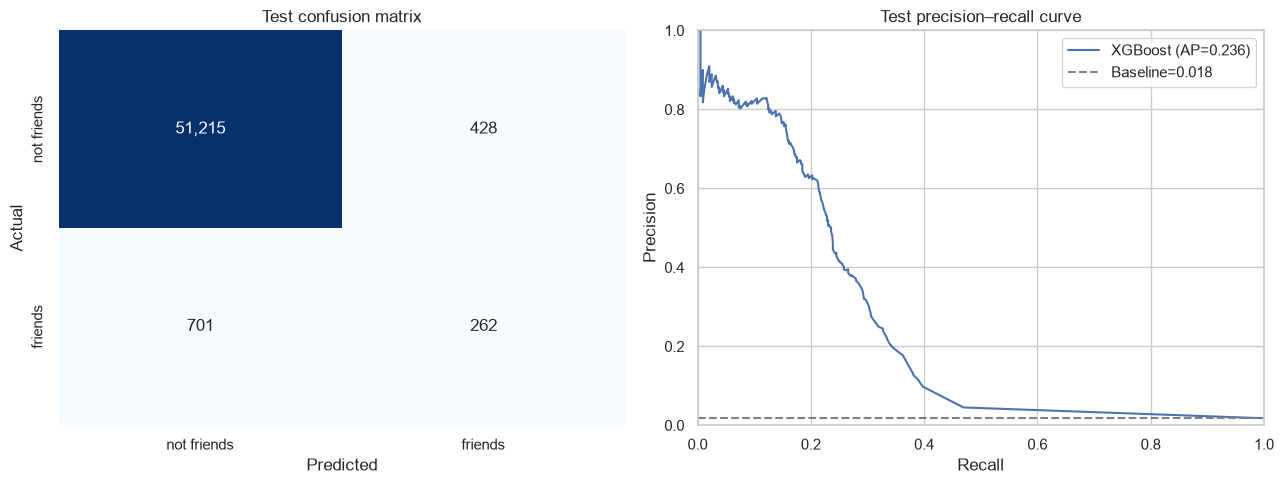

In [11]:
test_precision, test_recall, _ = precision_recall_curve(y_test, test_probability)
matrix = confusion_matrix(y_test, test_prediction)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(
    matrix,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=["not friends", "friends"],
    yticklabels=["not friends", "friends"],
    ax=axes[0],
)
axes[0].set(title="Test confusion matrix", xlabel="Predicted", ylabel="Actual")

axes[1].plot(test_recall, test_precision, label=f"XGBoost (AP={average_precision_score(y_test, test_probability):.3f})")
axes[1].axhline(y_test.mean(), color="gray", linestyle="--", label=f"Baseline={y_test.mean():.3f}")
axes[1].set(
    title="Test precision–recall curve",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1),
)
axes[1].legend()
plt.tight_layout()
plt.show()

## Model feature importance

Categorical proximity is expanded into one indicator per category, so those indicators appear separately below. XGBoost gain importance is useful for describing this fitted model but should not be interpreted as causal evidence.

,transformed_feature,importance
0,in_person_contact_minutes,0.270721
1,proximity_signal_category_moderate,0.201988
2,texts_shared,0.119214
3,proximity_signal_category_no_measurement,0.118232
4,longest_consecutive_text_streak_days,0.096852
5,proximity_signal_category_strong,0.088812
6,proximity_signal_category_very_weak,0.034909
7,proximity_signal_category_weak,0.031424
8,calls_shared,0.030777
9,proximity_signal_category_very_strong,0.007071


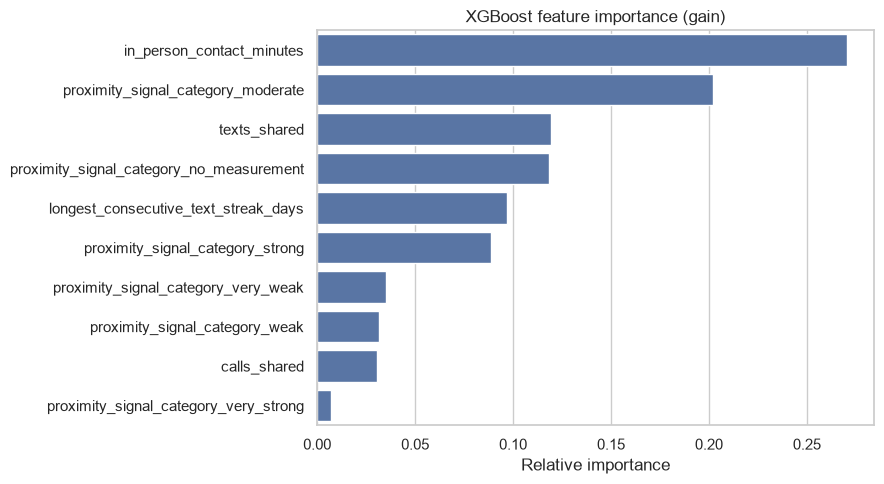

In [12]:
importance_df = (
    pd.DataFrame(
        {
            "transformed_feature": transformed_feature_names,
            "importance": model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(importance_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x="importance", y="transformed_feature", color="#4C72B0")
plt.title("XGBoost feature importance (gain)")
plt.xlabel("Relative importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Reusing or extending the model

- Increase `N_FEATURES` near the top of the notebook to test the next features in the supplied ranking, then rerun all cells.
- Keep feature selection and hyperparameter decisions confined to training/validation data; reserve the test split for the final comparison.
- The fitted objects are `preprocessor` and `model`, and the probability-to-class cutoff is `decision_threshold`.
- This model predicts recorded Facebook edges, which are an imperfect proxy for real-world friendship.

# Ten-feature comparison model

This second experiment keeps the original five-feature model unchanged and adds features six through ten from the supplied ranking. It uses the exact same train, validation, and test row indices, preprocessing rules, hyperparameters, class weight, and validation strategy so that the comparison isolates the effect of adding the five features.

In [13]:
FEATURES_10 = FEATURE_RANKING[:10]
ADDED_FEATURES = FEATURES_10[5:]

missing_ten_feature_columns = set(FEATURES_10).difference(features_df.columns)
if missing_ten_feature_columns:
    raise ValueError(
        f"Missing required ten-feature columns: {sorted(missing_ten_feature_columns)}"
    )

# Reuse the original split indices for a paired, apples-to-apples comparison.
X_train_10 = features_df.loc[y_train.index, FEATURES_10].copy()
X_validation_10 = features_df.loc[y_validation.index, FEATURES_10].copy()
X_test_10 = features_df.loc[y_test.index, FEATURES_10].copy()

assert X_train_10.index.equals(y_train.index)
assert X_validation_10.index.equals(y_validation.index)
assert X_test_10.index.equals(y_test.index)

print("Ten model features:")
display(pd.Series(FEATURES_10, name="feature", index=range(1, 11)).to_frame())
print(f"Newly added features: {ADDED_FEATURES}")

Ten model features:


,feature
1,texts_shared
2,calls_shared
3,proximity_signal_category
4,in_person_contact_minutes
5,longest_consecutive_text_streak_days
6,longest_consecutive_call_streak_days
7,days_texted
8,total_calls
9,days_called
10,call_reciprocity_category


Newly added features: ['longest_consecutive_call_streak_days', 'days_texted', 'total_calls', 'days_called', 'call_reciprocity_category']


In [14]:
categorical_features_10 = X_train_10.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()
numeric_features_10 = [
    column for column in FEATURES_10 if column not in categorical_features_10
]

preprocessor_10 = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_features_10,
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features_10,
        ),
    ],
    verbose_feature_names_out=False,
)

X_train_transformed_10 = preprocessor_10.fit_transform(X_train_10)
X_validation_transformed_10 = preprocessor_10.transform(X_validation_10)
X_test_transformed_10 = preprocessor_10.transform(X_test_10)
transformed_feature_names_10 = preprocessor_10.get_feature_names_out()

print(f"Numeric features: {numeric_features_10}")
print(f"Categorical features: {categorical_features_10}")
print(
    "Transformed matrix shapes: "
    f"{X_train_transformed_10.shape}, {X_validation_transformed_10.shape}, "
    f"{X_test_transformed_10.shape}"
)

Numeric features: ['texts_shared', 'calls_shared', 'in_person_contact_minutes', 'longest_consecutive_text_streak_days', 'longest_consecutive_call_streak_days', 'days_texted', 'total_calls', 'days_called']
Categorical features: ['proximity_signal_category', 'call_reciprocity_category']
Transformed matrix shapes: (245492, 22), (52605, 22), (52606, 22)


In [15]:
model_10 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=1_000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model_10.fit(
    X_train_transformed_10,
    y_train,
    eval_set=[(X_validation_transformed_10, y_validation)],
    verbose=50,
)

print(f"Training scale_pos_weight: {scale_pos_weight:.2f}")
print(f"Best boosting iteration: {model_10.best_iteration}")
print(f"Best validation AUCPR: {model_10.best_score:.4f}")

[0]	validation_0-aucpr:0.23563


[50]	validation_0-aucpr:0.23963


[100]	validation_0-aucpr:0.24242


[128]	validation_0-aucpr:0.23974


Training scale_pos_weight: 53.64
Best boosting iteration: 78
Best validation AUCPR: 0.2431


In [16]:
validation_probability_10 = model_10.predict_proba(
    X_validation_transformed_10
)[:, 1]
validation_precision_10, validation_recall_10, thresholds_10 = precision_recall_curve(
    y_validation, validation_probability_10
)
validation_f1_10 = (
    2 * validation_precision_10[:-1] * validation_recall_10[:-1]
    / (validation_precision_10[:-1] + validation_recall_10[:-1] + 1e-12)
)
best_threshold_index_10 = int(np.nanargmax(validation_f1_10))
decision_threshold_10 = float(thresholds_10[best_threshold_index_10])

print(f"Validation-selected threshold: {decision_threshold_10:.4f}")
print(
    "Validation F1 at selected threshold: "
    f"{validation_f1_10[best_threshold_index_10]:.4f}"
)

Validation-selected threshold: 0.8813
Validation F1 at selected threshold: 0.3208


## Five versus ten features

The table reports each model at its own validation-selected F1 threshold. Probability-ranking metrics such as ROC AUC and PR AUC do not depend on that threshold. Test results were calculated only after all ten-feature model choices were fixed using training and validation data.

In [17]:
test_probability_10 = model_10.predict_proba(X_test_transformed_10)[:, 1]
test_prediction_10 = (test_probability_10 >= decision_threshold_10).astype(int)

metrics_table_10 = pd.DataFrame(
    {
        "validation": classification_metrics(
            y_validation, validation_probability_10, decision_threshold_10
        ),
        "test": classification_metrics(
            y_test, test_probability_10, decision_threshold_10
        ),
    }
).T

comparison_table = pd.concat(
    {"5 features": metrics_table, "10 features": metrics_table_10},
    names=["model", "split"],
)
display(comparison_table.style.format("{:.4f}"))

test_metric_change = metrics_table_10.loc["test"] - metrics_table.loc["test"]
print("Ten-feature minus five-feature test metrics:")
display(test_metric_change.to_frame("change").style.format("{:+.4f}"))

print("Ten-feature test classification report")
print(classification_report(
    y_test,
    test_prediction_10,
    target_names=["not Facebook friends", "Facebook friends"],
    digits=4,
    zero_division=0,
))

Ten-feature minus five-feature test metrics:


,change
ROC AUC,+0.0000
PR AUC (average precision),+0.0009
Accuracy,+0.0000
Balanced accuracy,+0.0000
Precision,+0.0000
Recall,+0.0000
F1,+0.0000


Ten-feature test classification report
                      precision    recall  f1-score   support

not Facebook friends     0.9865    0.9917    0.9891     51643
    Facebook friends     0.3797    0.2721    0.3170       963

            accuracy                         0.9785     52606
           macro avg     0.6831    0.6319    0.6530     52606
        weighted avg     0.9754    0.9785    0.9768     52606



### Result

Adding features six through ten produced only a **very small improvement in probability ranking** on the held-out test set: PR AUC increased from **0.2360 to 0.2370**, while ROC AUC remained **0.6750**. At each model's validation-selected F1 threshold, the test precision (**0.3797**), recall (**0.2721**), and F1 (**0.3170**) were unchanged. On this split and with these hyperparameters, the first ten features therefore do not provide a meaningful classification improvement over the first five.

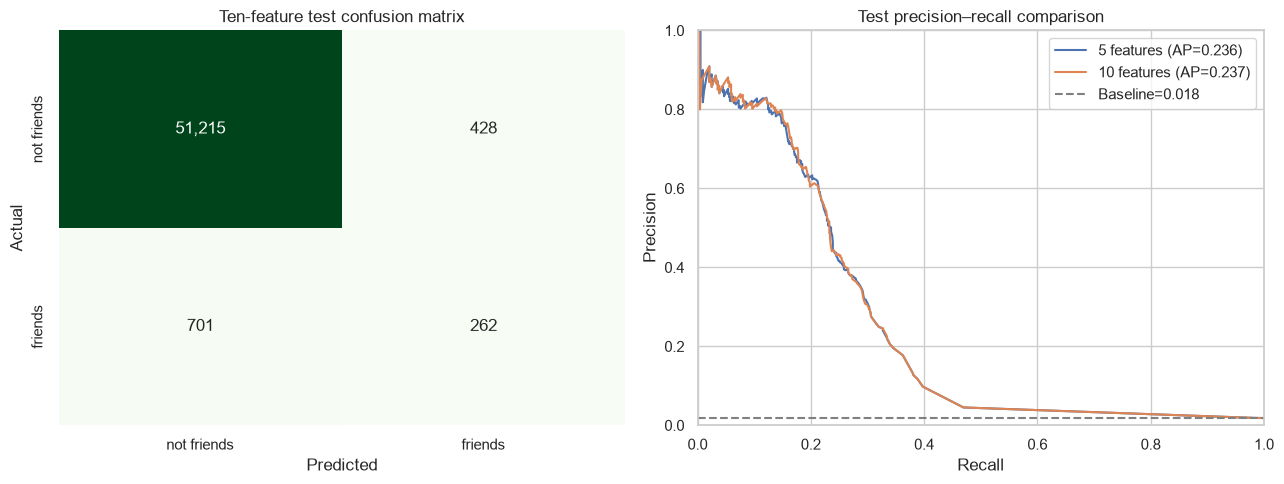

In [18]:
test_precision_10, test_recall_10, _ = precision_recall_curve(
    y_test, test_probability_10
)
matrix_10 = confusion_matrix(y_test, test_prediction_10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(
    matrix_10,
    annot=True,
    fmt=",d",
    cmap="Greens",
    cbar=False,
    xticklabels=["not friends", "friends"],
    yticklabels=["not friends", "friends"],
    ax=axes[0],
)
axes[0].set(
    title="Ten-feature test confusion matrix",
    xlabel="Predicted",
    ylabel="Actual",
)

axes[1].plot(
    test_recall,
    test_precision,
    label=f"5 features (AP={average_precision_score(y_test, test_probability):.3f})",
)
axes[1].plot(
    test_recall_10,
    test_precision_10,
    label=f"10 features (AP={average_precision_score(y_test, test_probability_10):.3f})",
)
axes[1].axhline(
    y_test.mean(), color="gray", linestyle="--", label=f"Baseline={y_test.mean():.3f}"
)
axes[1].set(
    title="Test precision–recall comparison",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1),
)
axes[1].legend()
plt.tight_layout()
plt.show()

,transformed_feature,importance
0,in_person_contact_minutes,0.249426
1,proximity_signal_category_moderate,0.222481
2,texts_shared,0.153599
3,proximity_signal_category_no_measurement,0.097099
4,proximity_signal_category_strong,0.077757
5,longest_consecutive_text_streak_days,0.064478
6,longest_consecutive_call_streak_days,0.023777
7,proximity_signal_category_weak,0.023341
8,calls_shared,0.023111
9,proximity_signal_category_very_weak,0.021095


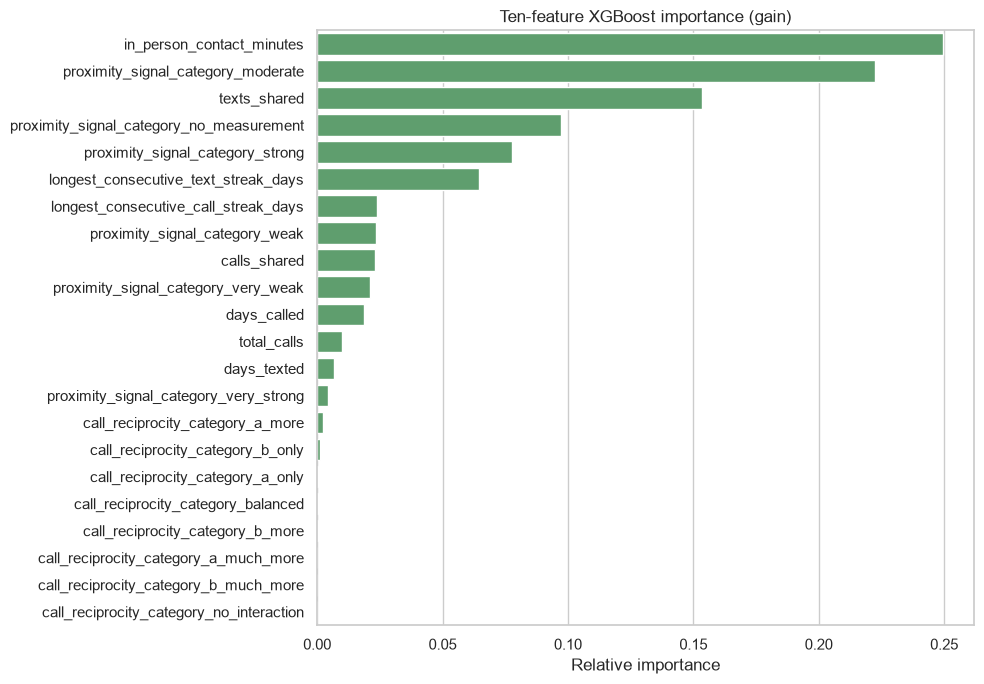

In [19]:
importance_df_10 = (
    pd.DataFrame(
        {
            "transformed_feature": transformed_feature_names_10,
            "importance": model_10.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(importance_df_10)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=importance_df_10,
    x="importance",
    y="transformed_feature",
    color="#55A868",
)
plt.title("Ten-feature XGBoost importance (gain)")
plt.xlabel("Relative importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Nine-feature model: remove duplicate `total_calls`

The data check below verifies that `calls_shared` and `total_calls` are identical for every pair. This experiment retains `calls_shared`, removes only `total_calls`, and otherwise duplicates the ten-feature experiment exactly. It uses the same split rows, preprocessing, XGBoost hyperparameters, validation early stopping, and validation-based F1 threshold.

In [20]:
calls_columns_identical = features_df["calls_shared"].equals(
    features_df["total_calls"]
)
assert calls_columns_identical, "The two call-count columns are no longer identical."

FEATURES_9_DEDUP = [feature for feature in FEATURES_10 if feature != "total_calls"]
assert len(FEATURES_9_DEDUP) == 9

X_train_9 = features_df.loc[y_train.index, FEATURES_9_DEDUP].copy()
X_validation_9 = features_df.loc[y_validation.index, FEATURES_9_DEDUP].copy()
X_test_9 = features_df.loc[y_test.index, FEATURES_9_DEDUP].copy()

print(f"calls_shared and total_calls identical: {calls_columns_identical}")
print("Retained features:")
display(pd.Series(FEATURES_9_DEDUP, name="feature", index=range(1, 10)).to_frame())

calls_shared and total_calls identical: True
Retained features:


,feature
1,texts_shared
2,calls_shared
3,proximity_signal_category
4,in_person_contact_minutes
5,longest_consecutive_text_streak_days
6,longest_consecutive_call_streak_days
7,days_texted
8,days_called
9,call_reciprocity_category


In [21]:
categorical_features_9 = X_train_9.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()
numeric_features_9 = [
    column for column in FEATURES_9_DEDUP if column not in categorical_features_9
]

preprocessor_9 = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_features_9,
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features_9,
        ),
    ],
    verbose_feature_names_out=False,
)

X_train_transformed_9 = preprocessor_9.fit_transform(X_train_9)
X_validation_transformed_9 = preprocessor_9.transform(X_validation_9)
X_test_transformed_9 = preprocessor_9.transform(X_test_9)

print(
    "Transformed matrix shapes: "
    f"{X_train_transformed_9.shape}, {X_validation_transformed_9.shape}, "
    f"{X_test_transformed_9.shape}"
)

Transformed matrix shapes: (245492, 21), (52605, 21), (52606, 21)


In [22]:
model_9 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=1_000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model_9.fit(
    X_train_transformed_9,
    y_train,
    eval_set=[(X_validation_transformed_9, y_validation)],
    verbose=50,
)

print(f"Best boosting iteration: {model_9.best_iteration}")
print(f"Best validation AUCPR: {model_9.best_score:.4f}")

[0]	validation_0-aucpr:0.23563


[50]	validation_0-aucpr:0.23848


[100]	validation_0-aucpr:0.24275


[143]	validation_0-aucpr:0.24106


Best boosting iteration: 93
Best validation AUCPR: 0.2436


In [23]:
validation_probability_9 = model_9.predict_proba(
    X_validation_transformed_9
)[:, 1]
validation_precision_9, validation_recall_9, thresholds_9 = precision_recall_curve(
    y_validation, validation_probability_9
)
validation_f1_9 = (
    2 * validation_precision_9[:-1] * validation_recall_9[:-1]
    / (validation_precision_9[:-1] + validation_recall_9[:-1] + 1e-12)
)
best_threshold_index_9 = int(np.nanargmax(validation_f1_9))
decision_threshold_9 = float(thresholds_9[best_threshold_index_9])

test_probability_9 = model_9.predict_proba(X_test_transformed_9)[:, 1]
test_prediction_9 = (test_probability_9 >= decision_threshold_9).astype(int)

metrics_table_9 = pd.DataFrame(
    {
        "validation": classification_metrics(
            y_validation, validation_probability_9, decision_threshold_9
        ),
        "test": classification_metrics(
            y_test, test_probability_9, decision_threshold_9
        ),
    }
).T

duplicate_feature_comparison = pd.DataFrame(
    {
        "10 features (with duplicate)": metrics_table_10.loc["test"],
        "9 features (duplicate removed)": metrics_table_9.loc["test"],
    }
).T
display(duplicate_feature_comparison.style.format("{:.4f}"))

print("Nine-feature minus ten-feature test metrics:")
display(
    (metrics_table_9.loc["test"] - metrics_table_10.loc["test"])
    .to_frame("change")
    .style.format("{:+.4f}")
)

print(f"Validation-selected threshold: {decision_threshold_9:.4f}")
print("Nine-feature test classification report")
print(classification_report(
    y_test,
    test_prediction_9,
    target_names=["not Facebook friends", "Facebook friends"],
    digits=4,
    zero_division=0,
))

,ROC AUC,PR AUC (average precision),Accuracy,Balanced accuracy,Precision,Recall,F1
10 features (with duplicate),0.6750,0.2370,0.9785,0.6319,0.3797,0.2721,0.3170
9 features (duplicate removed),0.6749,0.2369,0.9773,0.6379,0.3517,0.2856,0.3152


Nine-feature minus ten-feature test metrics:


,change
ROC AUC,-0.0000
PR AUC (average precision),-0.0000
Accuracy,-0.0013
Balanced accuracy,+0.0060
Precision,-0.0280
Recall,+0.0135
F1,-0.0018


Validation-selected threshold: 0.8856
Nine-feature test classification report
                      precision    recall  f1-score   support

not Facebook friends     0.9867    0.9902    0.9885     51643
    Facebook friends     0.3517    0.2856    0.3152       963

            accuracy                         0.9773     52606
           macro avg     0.6692    0.6379    0.6518     52606
        weighted avg     0.9751    0.9773    0.9761     52606



### Duplicate-removal result

Removing `total_calls` did **not** improve test PR AUC or F1. PR AUC was effectively unchanged (**0.2370 to 0.2369**) and F1 decreased slightly (**0.3170 to 0.3152**). The nine-feature model found more friendships—recall increased from **0.2721 to 0.2856** and balanced accuracy increased from **0.6319 to 0.6379**—but produced more false positives, reducing precision from **0.3797 to 0.3517**.

Because the two call-count columns are exactly identical, removing the duplicate remains the cleaner specification even though it did not improve this particular test score. The small prediction difference arises from XGBoost's column subsampling: changing the number of columns changes which predictors are randomly available to individual trees.

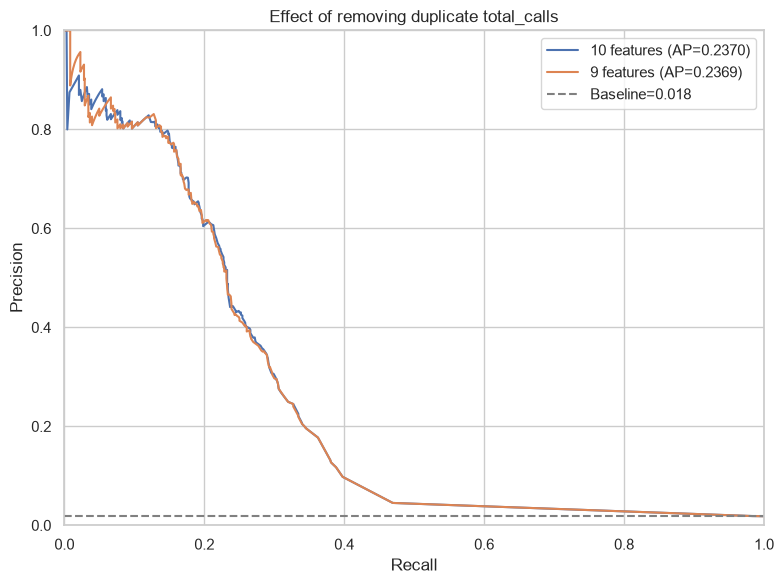

In [24]:
test_precision_9, test_recall_9, _ = precision_recall_curve(
    y_test, test_probability_9
)

plt.figure(figsize=(8, 6))
plt.plot(
    test_recall_10,
    test_precision_10,
    label=f"10 features (AP={average_precision_score(y_test, test_probability_10):.4f})",
)
plt.plot(
    test_recall_9,
    test_precision_9,
    label=f"9 features (AP={average_precision_score(y_test, test_probability_9):.4f})",
)
plt.axhline(
    y_test.mean(),
    color="gray",
    linestyle="--",
    label=f"Baseline={y_test.mean():.3f}",
)
plt.title("Effect of removing duplicate total_calls")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# Ten distinct features: add text reciprocity

This experiment preserves the nine-feature duplicate-removal model and adds the next unused feature from the original ranking: `text_reciprocity_category`. It therefore contains ten genuinely distinct input columns: `calls_shared` is retained, its duplicate `total_calls` remains excluded, and text reciprocity becomes the replacement tenth feature. All other training and evaluation settings match the nine-feature model.

In [25]:
REPLACEMENT_FEATURE = "text_reciprocity_category"
FEATURES_10_DISTINCT = [*FEATURES_9_DEDUP, REPLACEMENT_FEATURE]

assert len(FEATURES_10_DISTINCT) == 10
assert len(set(FEATURES_10_DISTINCT)) == 10
assert "calls_shared" in FEATURES_10_DISTINCT
assert "total_calls" not in FEATURES_10_DISTINCT

X_train_10_distinct = features_df.loc[
    y_train.index, FEATURES_10_DISTINCT
].copy()
X_validation_10_distinct = features_df.loc[
    y_validation.index, FEATURES_10_DISTINCT
].copy()
X_test_10_distinct = features_df.loc[
    y_test.index, FEATURES_10_DISTINCT
].copy()

print(f"Replacement tenth feature: {REPLACEMENT_FEATURE}")
display(pd.Series(FEATURES_10_DISTINCT, name="feature", index=range(1, 11)).to_frame())

Replacement tenth feature: text_reciprocity_category


,feature
1,texts_shared
2,calls_shared
3,proximity_signal_category
4,in_person_contact_minutes
5,longest_consecutive_text_streak_days
6,longest_consecutive_call_streak_days
7,days_texted
8,days_called
9,call_reciprocity_category
10,text_reciprocity_category


In [26]:
categorical_features_10_distinct = X_train_10_distinct.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()
numeric_features_10_distinct = [
    column
    for column in FEATURES_10_DISTINCT
    if column not in categorical_features_10_distinct
]

preprocessor_10_distinct = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_features_10_distinct,
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features_10_distinct,
        ),
    ],
    verbose_feature_names_out=False,
)

X_train_transformed_10_distinct = preprocessor_10_distinct.fit_transform(
    X_train_10_distinct
)
X_validation_transformed_10_distinct = preprocessor_10_distinct.transform(
    X_validation_10_distinct
)
X_test_transformed_10_distinct = preprocessor_10_distinct.transform(
    X_test_10_distinct
)

print(f"Numeric features: {numeric_features_10_distinct}")
print(f"Categorical features: {categorical_features_10_distinct}")
print(
    "Transformed matrix shapes: "
    f"{X_train_transformed_10_distinct.shape}, "
    f"{X_validation_transformed_10_distinct.shape}, "
    f"{X_test_transformed_10_distinct.shape}"
)

Numeric features: ['texts_shared', 'calls_shared', 'in_person_contact_minutes', 'longest_consecutive_text_streak_days', 'longest_consecutive_call_streak_days', 'days_texted', 'days_called']
Categorical features: ['proximity_signal_category', 'call_reciprocity_category', 'text_reciprocity_category']
Transformed matrix shapes: (245492, 29), (52605, 29), (52606, 29)


In [27]:
model_10_distinct = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=1_000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model_10_distinct.fit(
    X_train_transformed_10_distinct,
    y_train,
    eval_set=[(X_validation_transformed_10_distinct, y_validation)],
    verbose=50,
)

print(f"Best boosting iteration: {model_10_distinct.best_iteration}")
print(f"Best validation AUCPR: {model_10_distinct.best_score:.4f}")

[0]	validation_0-aucpr:0.23545


[50]	validation_0-aucpr:0.23834


[100]	validation_0-aucpr:0.24271


[140]	validation_0-aucpr:0.24015


Best boosting iteration: 90
Best validation AUCPR: 0.2449


In [28]:
validation_probability_10_distinct = model_10_distinct.predict_proba(
    X_validation_transformed_10_distinct
)[:, 1]
(
    validation_precision_10_distinct,
    validation_recall_10_distinct,
    thresholds_10_distinct,
) = precision_recall_curve(y_validation, validation_probability_10_distinct)
validation_f1_10_distinct = (
    2
    * validation_precision_10_distinct[:-1]
    * validation_recall_10_distinct[:-1]
    / (
        validation_precision_10_distinct[:-1]
        + validation_recall_10_distinct[:-1]
        + 1e-12
    )
)
best_threshold_index_10_distinct = int(np.nanargmax(validation_f1_10_distinct))
decision_threshold_10_distinct = float(
    thresholds_10_distinct[best_threshold_index_10_distinct]
)

test_probability_10_distinct = model_10_distinct.predict_proba(
    X_test_transformed_10_distinct
)[:, 1]
test_prediction_10_distinct = (
    test_probability_10_distinct >= decision_threshold_10_distinct
).astype(int)

metrics_table_10_distinct = pd.DataFrame(
    {
        "validation": classification_metrics(
            y_validation,
            validation_probability_10_distinct,
            decision_threshold_10_distinct,
        ),
        "test": classification_metrics(
            y_test,
            test_probability_10_distinct,
            decision_threshold_10_distinct,
        ),
    }
).T

distinct_feature_comparison = pd.DataFrame(
    {
        "9 features": metrics_table_9.loc["test"],
        "10 distinct features": metrics_table_10_distinct.loc["test"],
        "original 10 (included duplicate)": metrics_table_10.loc["test"],
    }
).T
display(distinct_feature_comparison.style.format("{:.4f}"))

print("Ten-distinct minus nine-feature test metrics:")
display(
    (metrics_table_10_distinct.loc["test"] - metrics_table_9.loc["test"])
    .to_frame("change")
    .style.format("{:+.4f}")
)

print(f"Validation-selected threshold: {decision_threshold_10_distinct:.4f}")
print("Ten-distinct-feature test classification report")
print(classification_report(
    y_test,
    test_prediction_10_distinct,
    target_names=["not Facebook friends", "Facebook friends"],
    digits=4,
    zero_division=0,
))

,ROC AUC,PR AUC (average precision),Accuracy,Balanced accuracy,Precision,Recall,F1
9 features,0.6749,0.2369,0.9773,0.6379,0.3517,0.2856,0.3152
10 distinct features,0.6749,0.2351,0.9773,0.6374,0.3517,0.2845,0.3146
original 10 (included duplicate),0.6750,0.2370,0.9785,0.6319,0.3797,0.2721,0.3170


Ten-distinct minus nine-feature test metrics:


,change
ROC AUC,+0.0000
PR AUC (average precision),-0.0018
Accuracy,+0.0000
Balanced accuracy,-0.0005
Precision,+0.0001
Recall,-0.0010
F1,-0.0006


Validation-selected threshold: 0.8812
Ten-distinct-feature test classification report
                      precision    recall  f1-score   support

not Facebook friends     0.9867    0.9902    0.9885     51643
    Facebook friends     0.3517    0.2845    0.3146       963

            accuracy                         0.9773     52606
           macro avg     0.6692    0.6374    0.6515     52606
        weighted avg     0.9751    0.9773    0.9761     52606



### Ten-distinct-feature result

Adding `text_reciprocity_category` as the replacement tenth feature did **not** improve the held-out test result. Compared with the nine-feature model, PR AUC decreased from **0.2369 to 0.2351** and F1 decreased slightly from **0.3152 to 0.3146**. Precision was effectively unchanged (**0.3517**), while recall decreased from **0.2856 to 0.2845**.

The model did achieve a slightly higher best validation AUCPR (**0.2449**), but that improvement did not generalize to the test set. This is a useful example of why final comparisons should include held-out or cross-validated performance rather than validation performance alone.

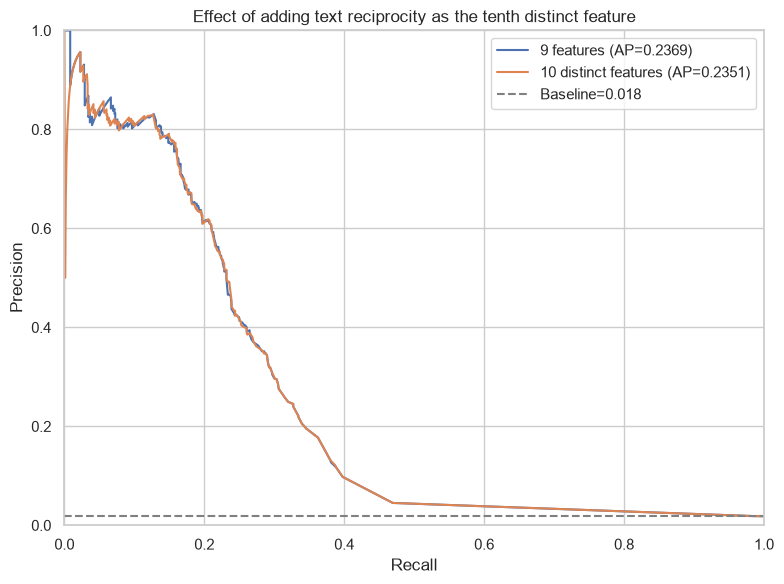

In [29]:
test_precision_10_distinct, test_recall_10_distinct, _ = precision_recall_curve(
    y_test, test_probability_10_distinct
)

plt.figure(figsize=(8, 6))
plt.plot(
    test_recall_9,
    test_precision_9,
    label=f"9 features (AP={average_precision_score(y_test, test_probability_9):.4f})",
)
plt.plot(
    test_recall_10_distinct,
    test_precision_10_distinct,
    label=(
        "10 distinct features "
        f"(AP={average_precision_score(y_test, test_probability_10_distinct):.4f})"
    ),
)
plt.axhline(
    y_test.mean(),
    color="gray",
    linestyle="--",
    label=f"Baseline={y_test.mean():.3f}",
)
plt.title("Effect of adding text reciprocity as the tenth distinct feature")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# Ten-feature model with cross-validation

This third experiment leaves both earlier models unchanged. It combines the original training and validation rows into an 85% **development set**, runs five-fold stratified cross-validation within that set, and keeps the original 15% test set untouched. Hyperparameters are selected by mean cross-validated average precision (PR AUC).

After selecting the hyperparameters, out-of-fold development predictions choose the F1 threshold. This prevents the threshold from being chosen on predictions made for rows used to fit that fold's model. The best pipeline is then refit on all development rows and evaluated once on the held-out test rows.

In [25]:
from sklearn.base import clone
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
)

# Reuse exactly the same rows as the first two experiments.
X_development_10 = pd.concat([X_train_10, X_validation_10])
y_development = pd.concat([y_train, y_validation])

assert X_development_10.index.equals(y_development.index)
assert set(X_development_10.index).isdisjoint(X_test_10.index)
assert len(X_development_10) + len(X_test_10) == len(features_df)

development_scale_pos_weight = (
    (y_development == 0).sum() / (y_development == 1).sum()
)

cv_splitter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

print(f"Development rows: {len(y_development):,} ({len(y_development) / len(y):.2%})")
print(f"Held-out test rows: {len(y_test):,} ({len(y_test) / len(y):.2%})")
print(f"Development friend rate: {y_development.mean():.3%}")
print(f"Development negative-to-positive ratio: {development_scale_pos_weight:.2f}")

Development rows: 298,097 (85.00%)
Held-out test rows: 52,606 (15.00%)
Development friend rate: 1.830%
Development negative-to-positive ratio: 53.65


In [26]:
cv_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor_10)),
        (
            "classifier",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="aucpr",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)

parameter_distributions = {
    "classifier__n_estimators": [200, 350, 500, 700],
    "classifier__learning_rate": [0.03, 0.05, 0.08, 0.10],
    "classifier__max_depth": [3, 4, 5, 6, 8],
    "classifier__min_child_weight": [1, 5, 10, 25],
    "classifier__gamma": [0, 0.25, 1, 3],
    "classifier__subsample": [0.70, 0.85, 1.0],
    "classifier__colsample_bytree": [0.70, 0.85, 1.0],
    "classifier__reg_alpha": [0, 0.10, 1.0],
    "classifier__reg_lambda": [1.0, 5.0, 10.0],
    "classifier__scale_pos_weight": [
        1.0,
        float(np.sqrt(development_scale_pos_weight)),
        20.0,
        float(development_scale_pos_weight),
    ],
    "classifier__max_delta_step": [0, 1, 5],
}

cv_search = RandomizedSearchCV(
    estimator=cv_pipeline,
    param_distributions=parameter_distributions,
    n_iter=12,
    scoring="average_precision",
    cv=cv_splitter,
    refit=True,
    random_state=RANDOM_STATE,
    n_jobs=2,
    verbose=1,
    return_train_score=False,
)

cv_search.fit(X_development_10, y_development)

print(f"Best mean cross-validated PR AUC: {cv_search.best_score_:.4f}")
print("Best parameters:")
display(pd.Series(cv_search.best_params_, name="value").to_frame())

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best mean cross-validated PR AUC: 0.2335
Best parameters:


,value
classifier__subsample,0.850000
classifier__scale_pos_weight,7.324381
classifier__reg_lambda,10.000000
classifier__reg_alpha,0.100000
classifier__n_estimators,350.000000
classifier__min_child_weight,5.000000
classifier__max_depth,4.000000
classifier__max_delta_step,0.000000
classifier__learning_rate,0.050000
classifier__gamma,0.250000


In [27]:
cv_results_df = pd.DataFrame(cv_search.cv_results_)
parameter_columns = [
    "param_classifier__n_estimators",
    "param_classifier__learning_rate",
    "param_classifier__max_depth",
    "param_classifier__scale_pos_weight",
    "param_classifier__max_delta_step",
]
top_cv_results = (
    cv_results_df[
        ["rank_test_score", "mean_test_score", "std_test_score", *parameter_columns]
    ]
    .sort_values("rank_test_score")
    .head(12)
    .rename(
        columns={
            "rank_test_score": "rank",
            "mean_test_score": "mean_cv_pr_auc",
            "std_test_score": "std_cv_pr_auc",
        }
    )
)
display(
    top_cv_results.style.format(
        {"mean_cv_pr_auc": "{:.4f}", "std_cv_pr_auc": "{:.4f}"}
    )
)

,rank,mean_cv_pr_auc,std_cv_pr_auc,param_classifier__n_estimators,param_classifier__learning_rate,param_classifier__max_depth,param_classifier__scale_pos_weight,param_classifier__max_delta_step
2,1,0.2335,0.0100,350,0.050000,4,7.324381,0
0,2,0.2327,0.0090,350,0.030000,3,1.000000,5
11,3,0.2320,0.0094,500,0.080000,4,7.324381,5
8,4,0.2316,0.0100,500,0.080000,6,1.000000,1
5,5,0.2313,0.0090,700,0.030000,6,1.000000,0
6,6,0.2304,0.0089,350,0.080000,6,1.000000,1
9,7,0.2294,0.0095,700,0.100000,5,53.646563,5
1,8,0.2290,0.0092,500,0.050000,6,20.000000,5
7,9,0.2290,0.0087,700,0.050000,8,53.646563,0
3,10,0.2286,0.0083,700,0.050000,8,1.000000,5


## Out-of-fold threshold selection

`cross_val_predict` fits the selected pipeline five more times. Every development-row probability is generated by a model that did not train on that row. These out-of-fold probabilities provide a less optimistic threshold estimate than fitted development predictions.

In [28]:
development_oof_probability = cross_val_predict(
    cv_search.best_estimator_,
    X_development_10,
    y_development,
    cv=cv_splitter,
    method="predict_proba",
    n_jobs=2,
)[:, 1]

oof_precision, oof_recall, oof_thresholds = precision_recall_curve(
    y_development, development_oof_probability
)
oof_f1 = (
    2 * oof_precision[:-1] * oof_recall[:-1]
    / (oof_precision[:-1] + oof_recall[:-1] + 1e-12)
)
best_oof_threshold_index = int(np.nanargmax(oof_f1))
decision_threshold_cv = float(oof_thresholds[best_oof_threshold_index])

print(
    "Out-of-fold development PR AUC: "
    f"{average_precision_score(y_development, development_oof_probability):.4f}"
)
print(f"Out-of-fold F1-selected threshold: {decision_threshold_cv:.4f}")
print(f"Out-of-fold F1 at selected threshold: {oof_f1[best_oof_threshold_index]:.4f}")

Out-of-fold development PR AUC: 0.2365
Out-of-fold F1-selected threshold: 0.5495
Out-of-fold F1 at selected threshold: 0.3165


In [29]:
# RandomizedSearchCV already refit this pipeline on all development rows.
model_cv = cv_search.best_estimator_
test_probability_cv = model_cv.predict_proba(X_test_10)[:, 1]
test_prediction_cv = (test_probability_cv >= decision_threshold_cv).astype(int)

metrics_cv = pd.DataFrame(
    {
        "development OOF": classification_metrics(
            y_development,
            development_oof_probability,
            decision_threshold_cv,
        ),
        "test": classification_metrics(
            y_test,
            test_probability_cv,
            decision_threshold_cv,
        ),
    }
).T

all_model_test_comparison = pd.DataFrame(
    {
        "5 features": metrics_table.loc["test"],
        "10 features": metrics_table_10.loc["test"],
        "10 features + CV tuning": metrics_cv.loc["test"],
    }
).T

display(metrics_cv.style.format("{:.4f}"))
print("Held-out test comparison")
display(all_model_test_comparison.style.format("{:.4f}"))

print("Cross-validated model test classification report")
print(classification_report(
    y_test,
    test_prediction_cv,
    target_names=["not Facebook friends", "Facebook friends"],
    digits=4,
    zero_division=0,
))

,ROC AUC,PR AUC (average precision),Accuracy,Balanced accuracy,Precision,Recall,F1
development OOF,0.6818,0.2365,0.9781,0.6340,0.3696,0.2768,0.3165
test,0.6750,0.2363,0.9781,0.6322,0.3673,0.2731,0.3133


Held-out test comparison


,ROC AUC,PR AUC (average precision),Accuracy,Balanced accuracy,Precision,Recall,F1
5 features,0.6750,0.2360,0.9785,0.6319,0.3797,0.2721,0.3170
10 features,0.6750,0.2370,0.9785,0.6319,0.3797,0.2721,0.3170
10 features + CV tuning,0.6750,0.2363,0.9781,0.6322,0.3673,0.2731,0.3133


Cross-validated model test classification report
                      precision    recall  f1-score   support

not Facebook friends     0.9865    0.9912    0.9889     51643
    Facebook friends     0.3673    0.2731    0.3133       963

            accuracy                         0.9781     52606
           macro avg     0.6769    0.6322    0.6511     52606
        weighted avg     0.9752    0.9781    0.9765     52606



### Cross-validation result

The search selected a substantially smaller class weight (**7.32** rather than **53.65**) and a shallower depth-four model. Its mean five-fold development PR AUC was **0.2335 ± 0.0100**, and its pooled out-of-fold development PR AUC was **0.2365**.

On the untouched test set, the cross-validated model achieved PR AUC **0.2363** and F1 **0.3133**. This did not beat the untuned ten-feature model's PR AUC (**0.2370**) or F1 (**0.3170**). Cross-validation provides a more reliable model-selection estimate, but it does not guarantee that the selected model will improve a particular held-out test result. The similar scores reinforce the earlier finding that the current feature set—rather than scaling or basic parameter choices—is the main performance limitation.

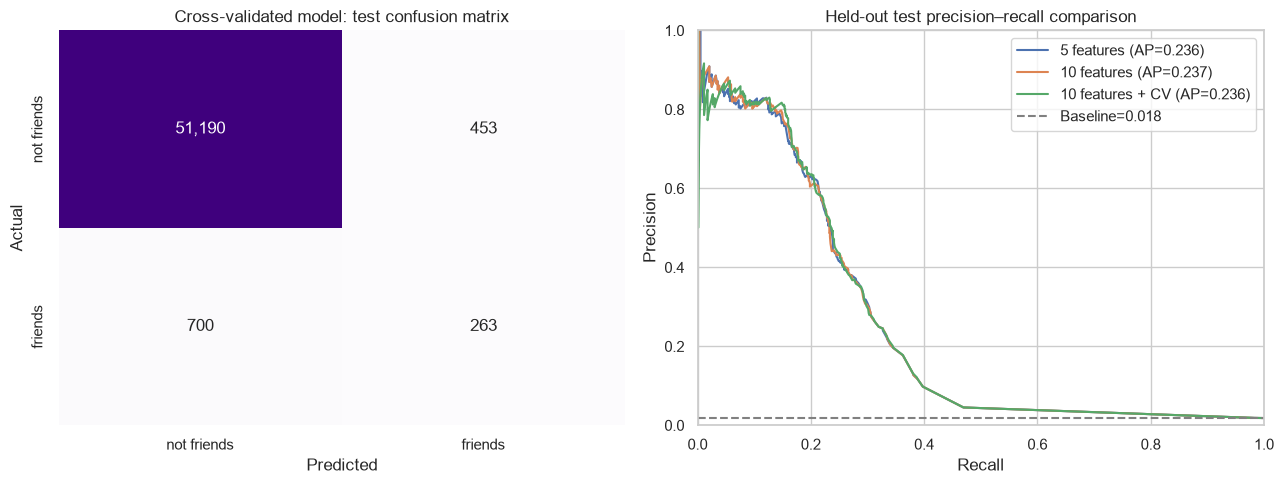

In [30]:
test_precision_cv, test_recall_cv, _ = precision_recall_curve(
    y_test, test_probability_cv
)
matrix_cv = confusion_matrix(y_test, test_prediction_cv)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(
    matrix_cv,
    annot=True,
    fmt=",d",
    cmap="Purples",
    cbar=False,
    xticklabels=["not friends", "friends"],
    yticklabels=["not friends", "friends"],
    ax=axes[0],
)
axes[0].set(
    title="Cross-validated model: test confusion matrix",
    xlabel="Predicted",
    ylabel="Actual",
)

axes[1].plot(
    test_recall,
    test_precision,
    label=f"5 features (AP={average_precision_score(y_test, test_probability):.3f})",
)
axes[1].plot(
    test_recall_10,
    test_precision_10,
    label=f"10 features (AP={average_precision_score(y_test, test_probability_10):.3f})",
)
axes[1].plot(
    test_recall_cv,
    test_precision_cv,
    label=(
        "10 features + CV "
        f"(AP={average_precision_score(y_test, test_probability_cv):.3f})"
    ),
)
axes[1].axhline(
    y_test.mean(),
    color="gray",
    linestyle="--",
    label=f"Baseline={y_test.mean():.3f}",
)
axes[1].set(
    title="Held-out test precision–recall comparison",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1),
)
axes[1].legend()
plt.tight_layout()
plt.show()

,transformed_feature,importance
0,in_person_contact_minutes,0.169197
1,proximity_signal_category_moderate,0.163342
2,call_reciprocity_category_no_interaction,0.152857
3,longest_consecutive_text_streak_days,0.125330
4,texts_shared,0.089225
5,days_texted,0.076669
6,proximity_signal_category_no_measurement,0.069725
7,longest_consecutive_call_streak_days,0.038525
8,calls_shared,0.032668
9,proximity_signal_category_strong,0.029061


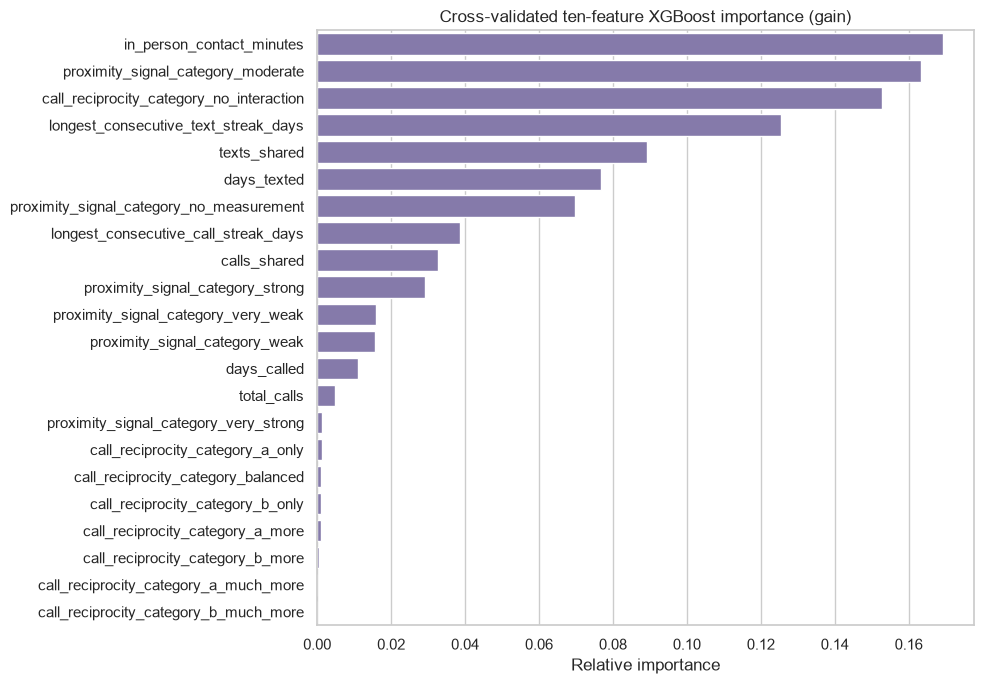

In [31]:
fitted_preprocessor_cv = model_cv.named_steps["preprocessor"]
fitted_classifier_cv = model_cv.named_steps["classifier"]
importance_df_cv = (
    pd.DataFrame(
        {
            "transformed_feature": fitted_preprocessor_cv.get_feature_names_out(),
            "importance": fitted_classifier_cv.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(importance_df_cv)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=importance_df_cv,
    x="importance",
    y="transformed_feature",
    color="#8172B2",
)
plt.title("Cross-validated ten-feature XGBoost importance (gain)")
plt.xlabel("Relative importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Five-fold ensemble with ten distinct features

This experiment keeps the same ten distinct features and changes only the training procedure. Five models are trained. Each model learns from a different 80% portion of the development data and uses the remaining 20% fold for early stopping.

### Why averaging five models makes sense

A single decision tree model can make some predictions because of small quirks in the rows it happened to see. The five models see slightly different training rows, so their individual mistakes will not always be the same. Averaging their five friendship probabilities reduces the influence of any one model's unusual mistake—similar to asking five informed people and averaging their estimates instead of relying on one person.

Early stopping also gives every fold model its own appropriate number of trees. Out-of-fold development predictions select the F1 threshold, and the original test rows remain excluded from training and threshold selection.

In [30]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

X_development_10_distinct = pd.concat(
    [X_train_10_distinct, X_validation_10_distinct]
)
y_development_ensemble = pd.concat([y_train, y_validation])

assert X_development_10_distinct.index.equals(y_development_ensemble.index)
assert set(X_development_10_distinct.index).isdisjoint(X_test_10_distinct.index)

ensemble_splitter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Parameters selected by the earlier randomized cross-validation search.
ENSEMBLE_PARAMETERS = {
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 5,
    "gamma": 0.25,
    "subsample": 0.85,
    "colsample_bytree": 0.70,
    "reg_alpha": 0.10,
    "reg_lambda": 10.0,
    "scale_pos_weight": 7.324381,
    "max_delta_step": 0,
}

print(f"Development rows: {len(y_development_ensemble):,}")
print(f"Held-out test rows: {len(y_test):,}")
display(pd.Series(ENSEMBLE_PARAMETERS, name="value").to_frame())

Development rows: 298,097
Held-out test rows: 52,606


,value
learning_rate,0.050000
max_depth,4.000000
min_child_weight,5.000000
gamma,0.250000
subsample,0.850000
colsample_bytree,0.700000
reg_alpha,0.100000
reg_lambda,10.000000
scale_pos_weight,7.324381
max_delta_step,0.000000


In [31]:
development_oof_probability_ensemble = np.zeros(
    len(y_development_ensemble), dtype=float
)
fold_test_probabilities = []
fold_ensemble_models = []
fold_training_summary = []

for fold_number, (fold_train_position, fold_validation_position) in enumerate(
    ensemble_splitter.split(X_development_10_distinct, y_development_ensemble),
    start=1,
):
    fold_X_train = X_development_10_distinct.iloc[fold_train_position]
    fold_y_train = y_development_ensemble.iloc[fold_train_position]
    fold_X_validation = X_development_10_distinct.iloc[fold_validation_position]
    fold_y_validation = y_development_ensemble.iloc[fold_validation_position]

    fold_preprocessor = clone(preprocessor_10_distinct)
    fold_X_train_transformed = fold_preprocessor.fit_transform(fold_X_train)
    fold_X_validation_transformed = fold_preprocessor.transform(
        fold_X_validation
    )
    fold_X_test_transformed = fold_preprocessor.transform(X_test_10_distinct)

    fold_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=1_500,
        early_stopping_rounds=50,
        tree_method="hist",
        random_state=RANDOM_STATE + fold_number,
        n_jobs=-1,
        **ENSEMBLE_PARAMETERS,
    )
    fold_model.fit(
        fold_X_train_transformed,
        fold_y_train,
        eval_set=[(fold_X_validation_transformed, fold_y_validation)],
        verbose=False,
    )

    fold_validation_probability = fold_model.predict_proba(
        fold_X_validation_transformed
    )[:, 1]
    development_oof_probability_ensemble[fold_validation_position] = (
        fold_validation_probability
    )
    fold_test_probabilities.append(
        fold_model.predict_proba(fold_X_test_transformed)[:, 1]
    )
    fold_ensemble_models.append((fold_preprocessor, fold_model))
    fold_training_summary.append(
        {
            "fold": fold_number,
            "best_iteration": fold_model.best_iteration,
            "validation_pr_auc": average_precision_score(
                fold_y_validation, fold_validation_probability
            ),
        }
    )
    print(
        f"Fold {fold_number}: best iteration={fold_model.best_iteration}, "
        f"validation PR AUC={fold_training_summary[-1]['validation_pr_auc']:.4f}"
    )

fold_training_summary_df = pd.DataFrame(fold_training_summary).set_index("fold")
display(fold_training_summary_df.style.format({"validation_pr_auc": "{:.4f}"}))

Fold 1: best iteration=40, validation PR AUC=0.2255


Fold 2: best iteration=70, validation PR AUC=0.2316


Fold 3: best iteration=54, validation PR AUC=0.2266


Fold 4: best iteration=97, validation PR AUC=0.2469


Fold 5: best iteration=183, validation PR AUC=0.2466


,best_iteration,validation_pr_auc
fold,,
1,40,0.2255
2,70,0.2316
3,54,0.2266
4,97,0.2469
5,183,0.2466


In [32]:
ensemble_test_probability = np.mean(fold_test_probabilities, axis=0)

ensemble_oof_precision, ensemble_oof_recall, ensemble_oof_thresholds = (
    precision_recall_curve(
        y_development_ensemble,
        development_oof_probability_ensemble,
    )
)
ensemble_oof_f1 = (
    2 * ensemble_oof_precision[:-1] * ensemble_oof_recall[:-1]
    / (ensemble_oof_precision[:-1] + ensemble_oof_recall[:-1] + 1e-12)
)
best_ensemble_threshold_index = int(np.nanargmax(ensemble_oof_f1))
decision_threshold_ensemble = float(
    ensemble_oof_thresholds[best_ensemble_threshold_index]
)
ensemble_test_prediction = (
    ensemble_test_probability >= decision_threshold_ensemble
).astype(int)

metrics_table_ensemble = pd.DataFrame(
    {
        "development OOF": classification_metrics(
            y_development_ensemble,
            development_oof_probability_ensemble,
            decision_threshold_ensemble,
        ),
        "test": classification_metrics(
            y_test,
            ensemble_test_probability,
            decision_threshold_ensemble,
        ),
    }
).T

ensemble_comparison = pd.DataFrame(
    {
        "9 features": metrics_table_9.loc["test"],
        "10 distinct features": metrics_table_10_distinct.loc["test"],
        "10 distinct + 5-fold ensemble": metrics_table_ensemble.loc["test"],
    }
).T

print(
    "Out-of-fold development PR AUC: "
    f"{average_precision_score(y_development_ensemble, development_oof_probability_ensemble):.4f}"
)
print(f"Out-of-fold selected threshold: {decision_threshold_ensemble:.4f}")
display(metrics_table_ensemble.style.format("{:.4f}"))
print("Held-out test comparison")
display(ensemble_comparison.style.format("{:.4f}"))

print("Five-fold ensemble test classification report")
print(classification_report(
    y_test,
    ensemble_test_prediction,
    target_names=["not Facebook friends", "Facebook friends"],
    digits=4,
    zero_division=0,
))

Out-of-fold development PR AUC: 0.2354
Out-of-fold selected threshold: 0.4942


,ROC AUC,PR AUC (average precision),Accuracy,Balanced accuracy,Precision,Recall,F1
development OOF,0.6837,0.2354,0.9777,0.6360,0.3613,0.2812,0.3163
test,0.6750,0.2391,0.9786,0.6324,0.3806,0.2731,0.3180


Held-out test comparison


,ROC AUC,PR AUC (average precision),Accuracy,Balanced accuracy,Precision,Recall,F1
9 features,0.6749,0.2369,0.9773,0.6379,0.3517,0.2856,0.3152
10 distinct features,0.6749,0.2351,0.9773,0.6374,0.3517,0.2845,0.3146
10 distinct + 5-fold ensemble,0.6750,0.2391,0.9786,0.6324,0.3806,0.2731,0.3180


Five-fold ensemble test classification report
                      precision    recall  f1-score   support

not Facebook friends     0.9865    0.9917    0.9891     51643
    Facebook friends     0.3806    0.2731    0.3180       963

            accuracy                         0.9786     52606
           macro avg     0.6836    0.6324    0.6536     52606
        weighted avg     0.9754    0.9786    0.9768     52606



### Ensemble result

The five-fold ensemble produced the **best test result so far**, although the improvement was modest. Test PR AUC increased to **0.2391** and F1 increased to **0.3180**. At the out-of-fold-selected threshold, precision was **0.3806** and recall was **0.2731**.

In simple terms, the ensemble helped because the five models did not make exactly the same errors. Averaging their probabilities reduced a small amount of model-specific noise. The ROC AUC remained approximately **0.675**, however, which indicates that averaging improved stability more than it improved the model's fundamental ability to separate friends from nonfriends.

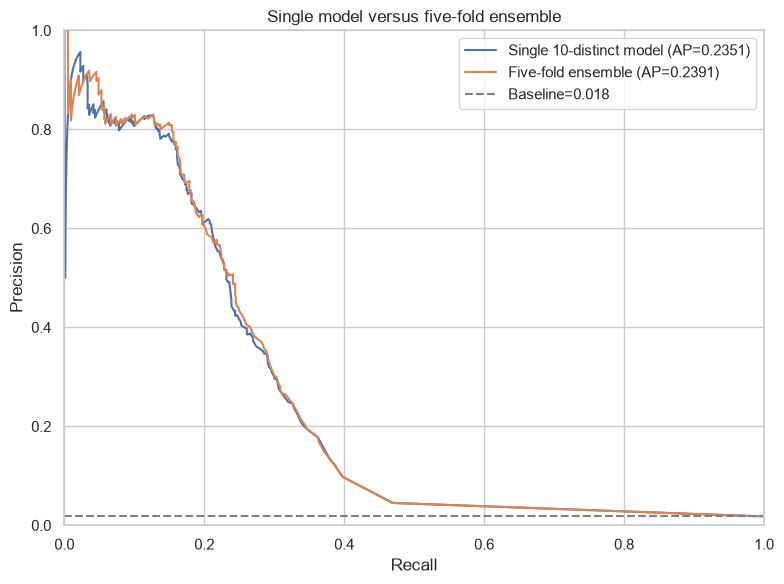

In [33]:
ensemble_test_precision, ensemble_test_recall, _ = precision_recall_curve(
    y_test, ensemble_test_probability
)

plt.figure(figsize=(8, 6))
plt.plot(
    test_recall_10_distinct,
    test_precision_10_distinct,
    label=(
        "Single 10-distinct model "
        f"(AP={average_precision_score(y_test, test_probability_10_distinct):.4f})"
    ),
)
plt.plot(
    ensemble_test_recall,
    ensemble_test_precision,
    label=(
        "Five-fold ensemble "
        f"(AP={average_precision_score(y_test, ensemble_test_probability):.4f})"
    ),
)
plt.axhline(
    y_test.mean(),
    color="gray",
    linestyle="--",
    label=f"Baseline={y_test.mean():.3f}",
)
plt.title("Single model versus five-fold ensemble")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# Targeted L1 and L2 regularization

XGBoost already supports both requested penalties:

- `reg_alpha` is **L1 regularization**. It encourages weak leaf contributions to become exactly zero, which can simplify the model.
- `reg_lambda` is **L2 regularization**. It smoothly shrinks large leaf contributions, making predictions less sensitive to individual training examples.

The preceding ensemble already uses `reg_alpha=0.10` and `reg_lambda=10`. More penalty is not automatically better: too little can overfit, while too much can erase useful signal. This section compares ten L1/L2 combinations with three-fold stratified cross-validation on development data only. It then trains a five-fold ensemble using the best regularization pair.

In [34]:
regularization_candidates = [
    {"reg_alpha": 0.0, "reg_lambda": 0.0},
    {"reg_alpha": 0.0, "reg_lambda": 1.0},
    {"reg_alpha": 0.0, "reg_lambda": 10.0},
    {"reg_alpha": 0.1, "reg_lambda": 1.0},
    {"reg_alpha": 0.1, "reg_lambda": 10.0},
    {"reg_alpha": 0.5, "reg_lambda": 5.0},
    {"reg_alpha": 0.5, "reg_lambda": 10.0},
    {"reg_alpha": 1.0, "reg_lambda": 10.0},
    {"reg_alpha": 1.0, "reg_lambda": 20.0},
    {"reg_alpha": 2.0, "reg_lambda": 20.0},
]

regularization_splitter = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE + 100,
)

base_regularized_parameters = {
    key: value
    for key, value in ENSEMBLE_PARAMETERS.items()
    if key not in {"reg_alpha", "reg_lambda"}
}
regularization_scores = {
    candidate_index: []
    for candidate_index in range(len(regularization_candidates))
}

for fold_number, (fold_train_position, fold_validation_position) in enumerate(
    regularization_splitter.split(
        X_development_10_distinct, y_development_ensemble
    ),
    start=1,
):
    fold_X_train = X_development_10_distinct.iloc[fold_train_position]
    fold_y_train = y_development_ensemble.iloc[fold_train_position]
    fold_X_validation = X_development_10_distinct.iloc[fold_validation_position]
    fold_y_validation = y_development_ensemble.iloc[fold_validation_position]

    fold_preprocessor = clone(preprocessor_10_distinct)
    fold_X_train_transformed = fold_preprocessor.fit_transform(fold_X_train)
    fold_X_validation_transformed = fold_preprocessor.transform(
        fold_X_validation
    )

    for candidate_index, candidate in enumerate(regularization_candidates):
        candidate_model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            n_estimators=1_200,
            early_stopping_rounds=40,
            tree_method="hist",
            random_state=RANDOM_STATE + fold_number,
            n_jobs=-1,
            **base_regularized_parameters,
            **candidate,
        )
        candidate_model.fit(
            fold_X_train_transformed,
            fold_y_train,
            eval_set=[(fold_X_validation_transformed, fold_y_validation)],
            verbose=False,
        )
        candidate_probability = candidate_model.predict_proba(
            fold_X_validation_transformed
        )[:, 1]
        regularization_scores[candidate_index].append(
            average_precision_score(fold_y_validation, candidate_probability)
        )

    print(f"Completed regularization fold {fold_number} of 3")

Completed regularization fold 1 of 3


Completed regularization fold 2 of 3


Completed regularization fold 3 of 3


In [35]:
regularization_results = pd.DataFrame(
    [
        {
            **candidate,
            "mean_cv_pr_auc": np.mean(regularization_scores[candidate_index]),
            "std_cv_pr_auc": np.std(
                regularization_scores[candidate_index], ddof=1
            ),
        }
        for candidate_index, candidate in enumerate(regularization_candidates)
    ]
).sort_values("mean_cv_pr_auc", ascending=False, ignore_index=True)

best_overall_reg_alpha = float(regularization_results.loc[0, "reg_alpha"])
best_overall_reg_lambda = float(regularization_results.loc[0, "reg_lambda"])
penalized_results = regularization_results.loc[
    (regularization_results["reg_alpha"] > 0)
    | (regularization_results["reg_lambda"] > 0)
].reset_index(drop=True)
best_reg_alpha = float(penalized_results.loc[0, "reg_alpha"])
best_reg_lambda = float(penalized_results.loc[0, "reg_lambda"])

display(
    regularization_results.style.format(
        {
            "reg_alpha": "{:.2f}",
            "reg_lambda": "{:.2f}",
            "mean_cv_pr_auc": "{:.4f}",
            "std_cv_pr_auc": "{:.4f}",
        }
    )
)
print(
    "Best overall control setting: "
    f"L1={best_overall_reg_alpha:.2f}, L2={best_overall_reg_lambda:.2f}"
)
print(f"Selected penalized L1 reg_alpha: {best_reg_alpha:.2f}")
print(f"Selected penalized L2 reg_lambda: {best_reg_lambda:.2f}")

,reg_alpha,reg_lambda,mean_cv_pr_auc,std_cv_pr_auc
0,0.00,0.00,0.2363,0.0087
1,0.50,10.00,0.2360,0.0084
2,0.50,5.00,0.2360,0.0087
3,0.00,1.00,0.2360,0.0087
4,1.00,10.00,0.2359,0.0087
5,2.00,20.00,0.2359,0.0091
6,0.10,1.00,0.2359,0.0082
7,0.00,10.00,0.2358,0.0087
8,1.00,20.00,0.2358,0.0086
9,0.10,10.00,0.2357,0.0088


Best overall control setting: L1=0.00, L2=0.00
Selected penalized L1 reg_alpha: 0.50
Selected penalized L2 reg_lambda: 10.00


In [36]:
regularized_oof_probability = np.zeros(
    len(y_development_ensemble), dtype=float
)
regularized_fold_test_probabilities = []
regularized_fold_models = []
regularized_fold_summary = []

for fold_number, (fold_train_position, fold_validation_position) in enumerate(
    ensemble_splitter.split(
        X_development_10_distinct, y_development_ensemble
    ),
    start=1,
):
    fold_X_train = X_development_10_distinct.iloc[fold_train_position]
    fold_y_train = y_development_ensemble.iloc[fold_train_position]
    fold_X_validation = X_development_10_distinct.iloc[fold_validation_position]
    fold_y_validation = y_development_ensemble.iloc[fold_validation_position]

    fold_preprocessor = clone(preprocessor_10_distinct)
    fold_X_train_transformed = fold_preprocessor.fit_transform(fold_X_train)
    fold_X_validation_transformed = fold_preprocessor.transform(
        fold_X_validation
    )
    fold_X_test_transformed = fold_preprocessor.transform(X_test_10_distinct)

    regularized_fold_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=1_500,
        early_stopping_rounds=50,
        tree_method="hist",
        random_state=RANDOM_STATE + fold_number,
        n_jobs=-1,
        **base_regularized_parameters,
        reg_alpha=best_reg_alpha,
        reg_lambda=best_reg_lambda,
    )
    regularized_fold_model.fit(
        fold_X_train_transformed,
        fold_y_train,
        eval_set=[(fold_X_validation_transformed, fold_y_validation)],
        verbose=False,
    )

    fold_validation_probability = regularized_fold_model.predict_proba(
        fold_X_validation_transformed
    )[:, 1]
    regularized_oof_probability[fold_validation_position] = (
        fold_validation_probability
    )
    regularized_fold_test_probabilities.append(
        regularized_fold_model.predict_proba(fold_X_test_transformed)[:, 1]
    )
    regularized_fold_models.append((fold_preprocessor, regularized_fold_model))
    fold_pr_auc = average_precision_score(
        fold_y_validation, fold_validation_probability
    )
    regularized_fold_summary.append(
        {
            "fold": fold_number,
            "best_iteration": regularized_fold_model.best_iteration,
            "validation_pr_auc": fold_pr_auc,
        }
    )
    print(
        f"Fold {fold_number}: best iteration={regularized_fold_model.best_iteration}, "
        f"validation PR AUC={fold_pr_auc:.4f}"
    )

Fold 1: best iteration=39, validation PR AUC=0.2253


Fold 2: best iteration=13, validation PR AUC=0.2271


Fold 3: best iteration=176, validation PR AUC=0.2279


Fold 4: best iteration=77, validation PR AUC=0.2465


Fold 5: best iteration=128, validation PR AUC=0.2465


In [37]:
regularized_ensemble_test_probability = np.mean(
    regularized_fold_test_probabilities, axis=0
)

regularized_oof_precision, regularized_oof_recall, regularized_oof_thresholds = (
    precision_recall_curve(
        y_development_ensemble,
        regularized_oof_probability,
    )
)
regularized_oof_f1 = (
    2 * regularized_oof_precision[:-1] * regularized_oof_recall[:-1]
    / (regularized_oof_precision[:-1] + regularized_oof_recall[:-1] + 1e-12)
)
best_regularized_threshold_index = int(np.nanargmax(regularized_oof_f1))
decision_threshold_regularized = float(
    regularized_oof_thresholds[best_regularized_threshold_index]
)
regularized_ensemble_test_prediction = (
    regularized_ensemble_test_probability >= decision_threshold_regularized
).astype(int)

metrics_table_regularized = pd.DataFrame(
    {
        "development OOF": classification_metrics(
            y_development_ensemble,
            regularized_oof_probability,
            decision_threshold_regularized,
        ),
        "test": classification_metrics(
            y_test,
            regularized_ensemble_test_probability,
            decision_threshold_regularized,
        ),
    }
).T

regularization_comparison = pd.DataFrame(
    {
        "single 10-distinct model": metrics_table_10_distinct.loc["test"],
        "original ensemble (L1=0.1, L2=10)": metrics_table_ensemble.loc["test"],
        "CV-selected regularized ensemble": metrics_table_regularized.loc["test"],
    }
).T

print(
    "Regularized out-of-fold development PR AUC: "
    f"{average_precision_score(y_development_ensemble, regularized_oof_probability):.4f}"
)
print(f"Out-of-fold selected threshold: {decision_threshold_regularized:.4f}")
display(metrics_table_regularized.style.format("{:.4f}"))
print("Held-out test comparison")
display(regularization_comparison.style.format("{:.4f}"))

print("Regularized ensemble test classification report")
print(classification_report(
    y_test,
    regularized_ensemble_test_prediction,
    target_names=["not Facebook friends", "Facebook friends"],
    digits=4,
    zero_division=0,
))

Regularized out-of-fold development PR AUC: 0.2161
Out-of-fold selected threshold: 0.4428


,ROC AUC,PR AUC (average precision),Accuracy,Balanced accuracy,Precision,Recall,F1
development OOF,0.6815,0.2161,0.9768,0.6352,0.3382,0.2807,0.3068
test,0.6704,0.2387,0.9778,0.6376,0.3629,0.2845,0.3190


Held-out test comparison


,ROC AUC,PR AUC (average precision),Accuracy,Balanced accuracy,Precision,Recall,F1
single 10-distinct model,0.6749,0.2351,0.9773,0.6374,0.3517,0.2845,0.3146
"original ensemble (L1=0.1, L2=10)",0.6750,0.2391,0.9786,0.6324,0.3806,0.2731,0.3180
CV-selected regularized ensemble,0.6704,0.2387,0.9778,0.6376,0.3629,0.2845,0.3190


Regularized ensemble test classification report
                      precision    recall  f1-score   support

not Facebook friends     0.9867    0.9907    0.9887     51643
    Facebook friends     0.3629    0.2845    0.3190       963

            accuracy                         0.9778     52606
           macro avg     0.6748    0.6376    0.6538     52606
        weighted avg     0.9753    0.9778    0.9764     52606



### Regularization result

The no-penalty control had the highest three-fold development PR AUC (**0.2363**), but its advantage over the best genuinely penalized setting (**0.2360**) was only 0.0003—much smaller than the variation among folds. The best penalized combination was **L1 `reg_alpha=0.5` and L2 `reg_lambda=10`**.

On the held-out test set, the stronger-regularized ensemble achieved the **best F1 so far, 0.3190**, and increased recall to **0.2845**. Its precision decreased to **0.3629**, however, and its PR AUC (**0.2387**) was slightly below the original ensemble's **0.2391**.

In simple terms, the added penalty changed the balance of mistakes: it found more real friendships but also created more false friendship predictions. If PR AUC and precision are the priority, retain the original ensemble (`L1=0.1`, `L2=10`). If F1 and recall are the priority, the stronger setting (`L1=0.5`, `L2=10`) is preferable.

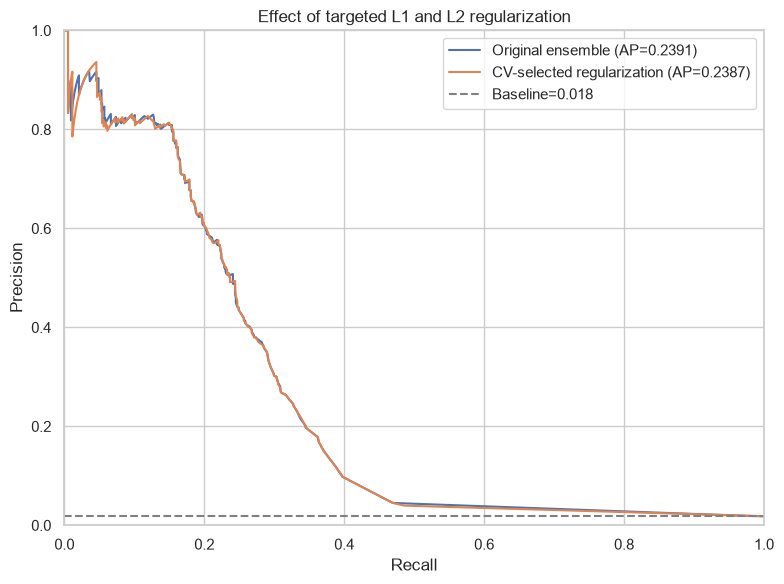

In [38]:
regularized_test_precision, regularized_test_recall, _ = precision_recall_curve(
    y_test, regularized_ensemble_test_probability
)

plt.figure(figsize=(8, 6))
plt.plot(
    ensemble_test_recall,
    ensemble_test_precision,
    label=(
        "Original ensemble "
        f"(AP={average_precision_score(y_test, ensemble_test_probability):.4f})"
    ),
)
plt.plot(
    regularized_test_recall,
    regularized_test_precision,
    label=(
        "CV-selected regularization "
        f"(AP={average_precision_score(y_test, regularized_ensemble_test_probability):.4f})"
    ),
)
plt.axhline(
    y_test.mean(),
    color="gray",
    linestyle="--",
    label=f"Baseline={y_test.mean():.3f}",
)
plt.title("Effect of targeted L1 and L2 regularization")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# Joint class-weight and threshold tuning

This section tunes `scale_pos_weight` and the classification threshold together while keeping the ten distinct features and other model settings fixed.

In simple terms, the class weight changes what the model pays attention to during learning. A larger value makes mistakes on friendships more expensive. The threshold acts afterward: a lower threshold labels more pairs as friends, while a higher threshold requires stronger evidence. Because both settings affect precision and recall, selecting them together using out-of-fold F1 is more reliable than adjusting either one in isolation.

Seven class weights are compared. Each weight receives out-of-fold predictions from five models, and its threshold is chosen using development data only. The test set is evaluated only after the winning pair is selected.

In [39]:
CLASS_WEIGHT_CANDIDATES = [1.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0]

weight_oof_probabilities = {
    weight: np.zeros(len(y_development_ensemble), dtype=float)
    for weight in CLASS_WEIGHT_CANDIDATES
}
weight_test_probabilities = {
    weight: [] for weight in CLASS_WEIGHT_CANDIDATES
}
class_weight_fold_models = {
    weight: [] for weight in CLASS_WEIGHT_CANDIDATES
}

weight_tuning_parameters = {
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 5,
    "gamma": 0.25,
    "subsample": 0.85,
    "colsample_bytree": 0.70,
    "reg_alpha": 0.50,
    "reg_lambda": 10.0,
    "max_delta_step": 0,
}

for fold_number, (fold_train_position, fold_validation_position) in enumerate(
    ensemble_splitter.split(
        X_development_10_distinct, y_development_ensemble
    ),
    start=1,
):
    fold_X_train = X_development_10_distinct.iloc[fold_train_position]
    fold_y_train = y_development_ensemble.iloc[fold_train_position]
    fold_X_validation = X_development_10_distinct.iloc[fold_validation_position]
    fold_y_validation = y_development_ensemble.iloc[fold_validation_position]

    fold_preprocessor = clone(preprocessor_10_distinct)
    fold_X_train_transformed = fold_preprocessor.fit_transform(fold_X_train)
    fold_X_validation_transformed = fold_preprocessor.transform(
        fold_X_validation
    )
    fold_X_test_transformed = fold_preprocessor.transform(X_test_10_distinct)

    for weight in CLASS_WEIGHT_CANDIDATES:
        weight_model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            n_estimators=1_500,
            early_stopping_rounds=50,
            tree_method="hist",
            random_state=RANDOM_STATE + fold_number,
            n_jobs=-1,
            scale_pos_weight=weight,
            **weight_tuning_parameters,
        )
        weight_model.fit(
            fold_X_train_transformed,
            fold_y_train,
            eval_set=[(fold_X_validation_transformed, fold_y_validation)],
            verbose=False,
        )

        weight_oof_probabilities[weight][fold_validation_position] = (
            weight_model.predict_proba(fold_X_validation_transformed)[:, 1]
        )
        weight_test_probabilities[weight].append(
            weight_model.predict_proba(fold_X_test_transformed)[:, 1]
        )
        class_weight_fold_models[weight].append(
            (fold_preprocessor, weight_model)
        )

    print(f"Completed class-weight fold {fold_number} of 5")

Completed class-weight fold 1 of 5


Completed class-weight fold 2 of 5


Completed class-weight fold 3 of 5


Completed class-weight fold 4 of 5


Completed class-weight fold 5 of 5


In [40]:
weight_threshold_rows = []

for weight in CLASS_WEIGHT_CANDIDATES:
    oof_probability = weight_oof_probabilities[weight]
    weight_precision, weight_recall, weight_thresholds = precision_recall_curve(
        y_development_ensemble, oof_probability
    )
    weight_f1 = (
        2 * weight_precision[:-1] * weight_recall[:-1]
        / (weight_precision[:-1] + weight_recall[:-1] + 1e-12)
    )
    best_index = int(np.nanargmax(weight_f1))
    weight_threshold_rows.append(
        {
            "scale_pos_weight": weight,
            "oof_pr_auc": average_precision_score(
                y_development_ensemble, oof_probability
            ),
            "best_threshold": float(weight_thresholds[best_index]),
            "oof_precision": float(weight_precision[best_index]),
            "oof_recall": float(weight_recall[best_index]),
            "oof_f1": float(weight_f1[best_index]),
        }
    )

weight_threshold_results = (
    pd.DataFrame(weight_threshold_rows)
    .sort_values("oof_f1", ascending=False)
    .reset_index(drop=True)
)
selected_scale_pos_weight = float(
    weight_threshold_results.loc[0, "scale_pos_weight"]
)
selected_weight_threshold = float(
    weight_threshold_results.loc[0, "best_threshold"]
)

display(weight_threshold_results.style.format("{:.4f}"))
print(f"Selected scale_pos_weight: {selected_scale_pos_weight:.1f}")
print(f"Selected probability threshold: {selected_weight_threshold:.4f}")

,scale_pos_weight,oof_pr_auc,best_threshold,oof_precision,oof_recall,oof_f1
0,20.0000,0.2337,0.7809,0.4095,0.2587,0.3170
1,3.0000,0.2363,0.2877,0.3609,0.2827,0.3170
2,10.0000,0.2359,0.6057,0.3847,0.2693,0.3168
3,15.0000,0.2354,0.6978,0.3907,0.2664,0.3168
4,1.0000,0.2378,0.1505,0.3852,0.2689,0.3167
5,7.0000,0.2355,0.5274,0.3889,0.2667,0.3164
6,5.0000,0.2365,0.4617,0.4020,0.2609,0.3164


Selected scale_pos_weight: 20.0
Selected probability threshold: 0.7809


In [41]:
selected_weight_oof_probability = weight_oof_probabilities[
    selected_scale_pos_weight
]
selected_weight_test_probability = np.mean(
    weight_test_probabilities[selected_scale_pos_weight], axis=0
)
selected_weight_test_prediction = (
    selected_weight_test_probability >= selected_weight_threshold
).astype(int)
selected_weight_models = class_weight_fold_models[selected_scale_pos_weight]

metrics_table_weight_threshold = pd.DataFrame(
    {
        "development OOF": classification_metrics(
            y_development_ensemble,
            selected_weight_oof_probability,
            selected_weight_threshold,
        ),
        "test": classification_metrics(
            y_test,
            selected_weight_test_probability,
            selected_weight_threshold,
        ),
    }
).T

weight_threshold_comparison = pd.DataFrame(
    {
        "original ensemble": metrics_table_ensemble.loc["test"],
        "stronger-regularized ensemble": metrics_table_regularized.loc["test"],
        "joint weight + threshold tuning": metrics_table_weight_threshold.loc["test"],
    }
).T

display(metrics_table_weight_threshold.style.format("{:.4f}"))
print("Held-out test comparison")
display(weight_threshold_comparison.style.format("{:.4f}"))

print("Jointly tuned model test classification report")
print(classification_report(
    y_test,
    selected_weight_test_prediction,
    target_names=["not Facebook friends", "Facebook friends"],
    digits=4,
    zero_division=0,
))

,ROC AUC,PR AUC (average precision),Accuracy,Balanced accuracy,Precision,Recall,F1
development OOF,0.6836,0.2337,0.9796,0.6259,0.4095,0.2587,0.3170
test,0.6750,0.2380,0.9794,0.6267,0.4042,0.2606,0.3169


Held-out test comparison


,ROC AUC,PR AUC (average precision),Accuracy,Balanced accuracy,Precision,Recall,F1
original ensemble,0.6750,0.2391,0.9786,0.6324,0.3806,0.2731,0.3180
stronger-regularized ensemble,0.6704,0.2387,0.9778,0.6376,0.3629,0.2845,0.3190
joint weight + threshold tuning,0.6750,0.2380,0.9794,0.6267,0.4042,0.2606,0.3169


Jointly tuned model test classification report
                      precision    recall  f1-score   support

not Facebook friends     0.9863    0.9928    0.9896     51643
    Facebook friends     0.4042    0.2606    0.3169       963

            accuracy                         0.9794     52606
           macro avg     0.6952    0.6267    0.6532     52606
        weighted avg     0.9756    0.9794    0.9772     52606



### Joint-tuning result

Out-of-fold F1 selected **`scale_pos_weight=20`** and a probability threshold of **0.7809**. On the held-out test set, this produced the **highest precision so far, 0.4042**: about 40 of every 100 predicted friendships were correct. Recall decreased to **0.2606**, however, and F1 was **0.3169**.

In simple terms, the larger class weight made the model pay more attention to friendship examples while learning, and the high threshold then accepted only its more confident friendship scores. That combination made positive predictions more trustworthy, but it also rejected more real friendships.

This setting is preferable if **precision** is the priority. The stronger-regularized ensemble remains preferable if **F1 and recall** are the priority. No class-weight/threshold combination raised precision, recall, and F1 simultaneously, because threshold changes redistribute false positives and false negatives rather than adding new predictive information.

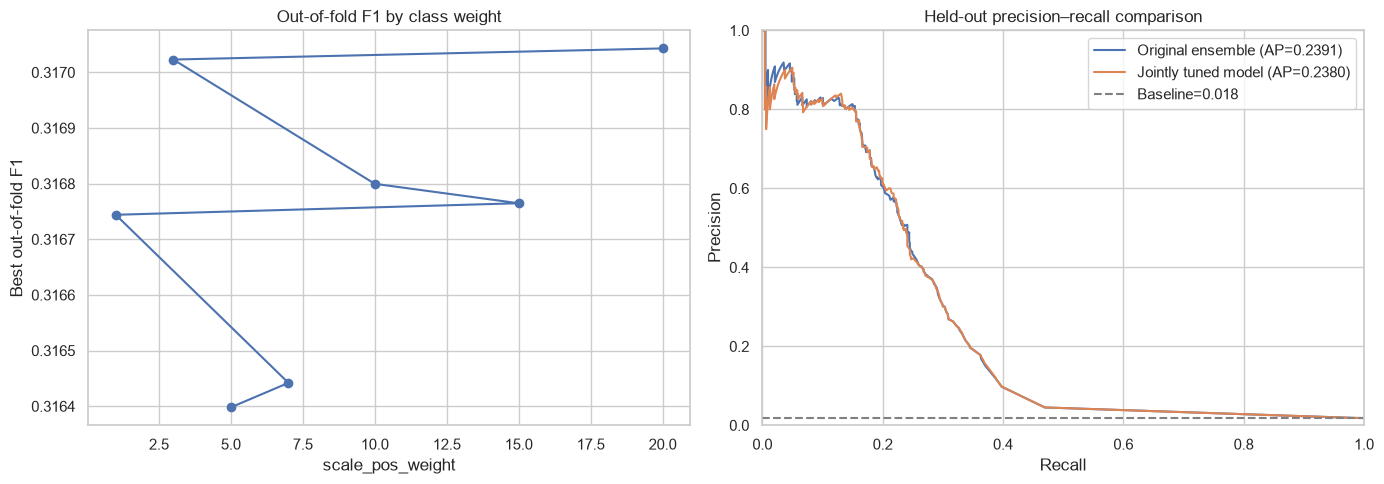

In [42]:
selected_test_precision, selected_test_recall, _ = precision_recall_curve(
    y_test, selected_weight_test_probability
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(
    weight_threshold_results["scale_pos_weight"],
    weight_threshold_results["oof_f1"],
    marker="o",
)
axes[0].set(
    title="Out-of-fold F1 by class weight",
    xlabel="scale_pos_weight",
    ylabel="Best out-of-fold F1",
)

axes[1].plot(
    ensemble_test_recall,
    ensemble_test_precision,
    label=f"Original ensemble (AP={average_precision_score(y_test, ensemble_test_probability):.4f})",
)
axes[1].plot(
    selected_test_recall,
    selected_test_precision,
    label=(
        "Jointly tuned model "
        f"(AP={average_precision_score(y_test, selected_weight_test_probability):.4f})"
    ),
)
axes[1].axhline(
    y_test.mean(),
    color="gray",
    linestyle="--",
    label=f"Baseline={y_test.mean():.3f}",
)
axes[1].set(
    title="Held-out precision–recall comparison",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1),
)
axes[1].legend()
plt.tight_layout()
plt.show()

# Overfitting diagnostic

Overfitting means a model performs substantially better on rows it trained on than on unseen rows. This section measures that gap for every model in the jointly tuned five-fold ensemble.

For each fold, PR AUC and ROC AUC are calculated twice: once on that model's training rows and once on its held-out fold. A positive training-minus-validation gap is expected because the model directly optimized its training rows. A large, consistent gap would indicate that it memorized training-specific patterns rather than learning relationships that generalize.

The current workflow already limits overfitting through depth-four trees, `min_child_weight`, `gamma`, row and column subsampling, L1/L2 penalties, five-fold validation, and early stopping.

In [43]:
overfitting_rows = []

fold_indices = list(
    ensemble_splitter.split(
        X_development_10_distinct, y_development_ensemble
    )
)

for fold_number, (
    (fold_train_position, fold_validation_position),
    (fold_preprocessor, fold_model),
) in enumerate(zip(fold_indices, selected_weight_models), start=1):
    fold_X_train = X_development_10_distinct.iloc[fold_train_position]
    fold_y_train = y_development_ensemble.iloc[fold_train_position]
    fold_X_validation = X_development_10_distinct.iloc[fold_validation_position]
    fold_y_validation = y_development_ensemble.iloc[fold_validation_position]

    fold_train_probability = fold_model.predict_proba(
        fold_preprocessor.transform(fold_X_train)
    )[:, 1]
    fold_validation_probability = fold_model.predict_proba(
        fold_preprocessor.transform(fold_X_validation)
    )[:, 1]

    train_pr_auc = average_precision_score(
        fold_y_train, fold_train_probability
    )
    validation_pr_auc = average_precision_score(
        fold_y_validation, fold_validation_probability
    )
    train_roc_auc = roc_auc_score(fold_y_train, fold_train_probability)
    validation_roc_auc = roc_auc_score(
        fold_y_validation, fold_validation_probability
    )

    overfitting_rows.append(
        {
            "fold": fold_number,
            "best_iteration": fold_model.best_iteration,
            "train_pr_auc": train_pr_auc,
            "validation_pr_auc": validation_pr_auc,
            "pr_auc_gap": train_pr_auc - validation_pr_auc,
            "train_roc_auc": train_roc_auc,
            "validation_roc_auc": validation_roc_auc,
            "roc_auc_gap": train_roc_auc - validation_roc_auc,
        }
    )

overfitting_diagnostic_df = pd.DataFrame(overfitting_rows).set_index("fold")
display(overfitting_diagnostic_df.style.format("{:.4f}"))

mean_overfitting_summary = overfitting_diagnostic_df.mean().to_frame(
    "mean_across_folds"
)
print("Mean diagnostic values")
display(mean_overfitting_summary.style.format("{:.4f}"))

,best_iteration,train_pr_auc,validation_pr_auc,pr_auc_gap,train_roc_auc,validation_roc_auc,roc_auc_gap
fold,,,,,,,
1,62.0000,0.2364,0.2264,0.0099,0.6853,0.6724,0.0130
2,54.0000,0.2349,0.2295,0.0054,0.6828,0.6825,0.0003
3,258.0000,0.2495,0.2289,0.0207,0.6830,0.6901,-0.0071
4,112.0000,0.2395,0.2476,-0.0080,0.6830,0.6901,-0.0071
5,192.0000,0.2427,0.2469,-0.0042,0.6854,0.6806,0.0048


Mean diagnostic values


,mean_across_folds
best_iteration,135.6000
train_pr_auc,0.2406
validation_pr_auc,0.2359
pr_auc_gap,0.0048
train_roc_auc,0.6839
validation_roc_auc,0.6831
roc_auc_gap,0.0008


### Overfitting result

The diagnostic does **not** show meaningful overall overfitting. Mean training PR AUC was **0.2406**, compared with **0.2359** on unseen folds, for a small gap of **0.0048**. Mean training ROC AUC was **0.6839**, compared with **0.6831** on unseen folds, for a gap of only **0.0008**.

Fold 3 had the largest PR-AUC gap (**0.0207**), but folds 4 and 5 performed better on their unseen validation rows than on their training rows. Overfitting would normally produce consistently higher training performance across folds, which is not present here.

In simple terms, the model performs almost as well on rows it did not train on as it does on rows it saw during training. The existing early stopping, shallow tree depth, subsampling, cross-validation, and regularization are therefore accounting for overfitting effectively. The remaining performance limitation is more consistent with limited separability in the current features than with memorization.

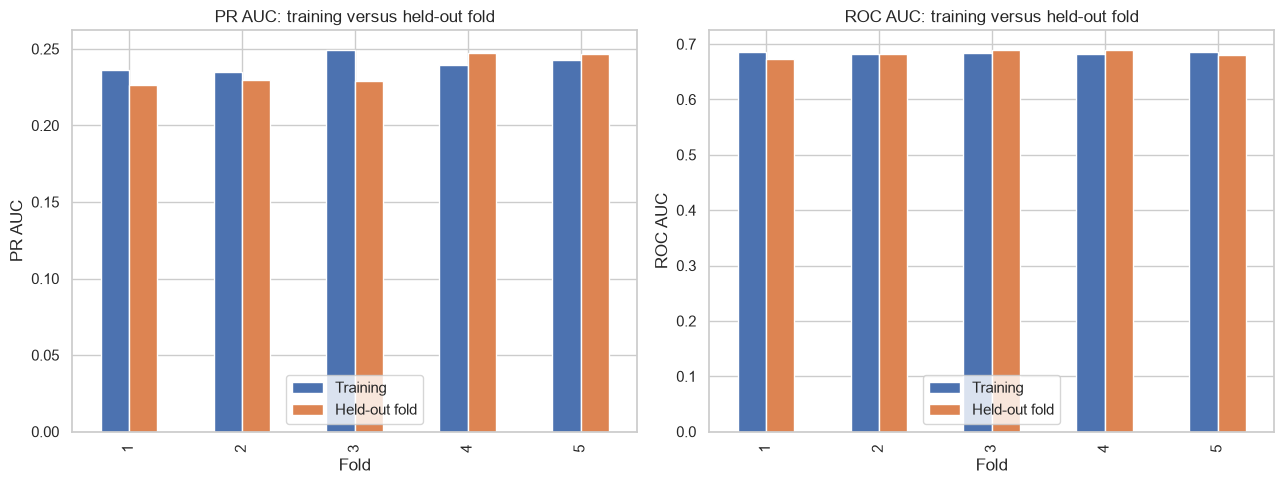

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

overfitting_diagnostic_df[["train_pr_auc", "validation_pr_auc"]].plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"]
)
axes[0].set(
    title="PR AUC: training versus held-out fold",
    xlabel="Fold",
    ylabel="PR AUC",
)
axes[0].legend(["Training", "Held-out fold"])

overfitting_diagnostic_df[["train_roc_auc", "validation_roc_auc"]].plot(
    kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"]
)
axes[1].set(
    title="ROC AUC: training versus held-out fold",
    xlabel="Fold",
    ylabel="ROC AUC",
)
axes[1].legend(["Training", "Held-out fold"])

plt.tight_layout()
plt.show()

# High-precision operating point

The deployment requirement is at least **60% friendship precision**. Because performance can decrease when moving from development data to unseen data, this section uses a stricter **65% out-of-fold development target** as a safety margin.

For every previously trained class-weight ensemble, the code finds the threshold that retains the most friendships while achieving at least 65% out-of-fold precision. It then selects the class weight with the highest remaining recall. Neither the class weight nor threshold is selected using test labels.

A 60% precision requirement means that at least 60 of every 100 predicted friendships should be correct. Meeting it will generally reduce recall because the model must make fewer, more conservative friendship predictions.

In [45]:
REQUIRED_TEST_PRECISION = 0.60
DEVELOPMENT_PRECISION_TARGET = 0.65
MINIMUM_DEVELOPMENT_PREDICTIONS = 100

high_precision_candidates = []

for weight in CLASS_WEIGHT_CANDIDATES:
    oof_probability = weight_oof_probabilities[weight]
    candidate_precision, candidate_recall, candidate_thresholds = (
        precision_recall_curve(y_development_ensemble, oof_probability)
    )

    for threshold_index, threshold in enumerate(candidate_thresholds):
        predicted_count = int((oof_probability >= threshold).sum())
        if (
            candidate_precision[threshold_index] >= DEVELOPMENT_PRECISION_TARGET
            and predicted_count >= MINIMUM_DEVELOPMENT_PREDICTIONS
        ):
            high_precision_candidates.append(
                {
                    "scale_pos_weight": weight,
                    "threshold": float(threshold),
                    "development_precision": float(
                        candidate_precision[threshold_index]
                    ),
                    "development_recall": float(
                        candidate_recall[threshold_index]
                    ),
                    "development_predictions": predicted_count,
                }
            )

if not high_precision_candidates:
    raise RuntimeError(
        "No class-weight/threshold pair met the conservative precision target."
    )

high_precision_candidates_df = (
    pd.DataFrame(high_precision_candidates)
    .sort_values(
        ["development_recall", "development_precision"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

selected_high_precision_weight = float(
    high_precision_candidates_df.loc[0, "scale_pos_weight"]
)
selected_high_precision_threshold = float(
    high_precision_candidates_df.loc[0, "threshold"]
)

print(f"Required held-out precision: {REQUIRED_TEST_PRECISION:.0%}")
print(f"Conservative development target: {DEVELOPMENT_PRECISION_TARGET:.0%}")
print(f"Selected scale_pos_weight: {selected_high_precision_weight:.1f}")
print(f"Selected threshold: {selected_high_precision_threshold:.4f}")
display(high_precision_candidates_df.head(10).style.format({
    "threshold": "{:.4f}",
    "development_precision": "{:.4f}",
    "development_recall": "{:.4f}",
}))

Required held-out precision: 60%
Conservative development target: 65%
Selected scale_pos_weight: 3.0
Selected threshold: 0.5495


,scale_pos_weight,threshold,development_precision,development_recall,development_predictions
0,3.000000,0.5495,0.6522,0.1736,1452
1,3.000000,0.5496,0.6526,0.1732,1448
2,3.000000,0.5497,0.6524,0.1731,1447
3,1.000000,0.3315,0.6515,0.1731,1449
4,1.000000,0.3303,0.6510,0.1731,1450
5,1.000000,0.3287,0.6506,0.1731,1451
6,3.000000,0.5540,0.6540,0.1729,1442
7,3.000000,0.5516,0.6535,0.1729,1443
8,1.000000,0.3335,0.6519,0.1727,1445
9,1.000000,0.3346,0.6521,0.1725,1443


In [46]:
high_precision_test_probability = np.mean(
    weight_test_probabilities[selected_high_precision_weight], axis=0
)
high_precision_test_prediction = (
    high_precision_test_probability >= selected_high_precision_threshold
).astype(int)

high_precision_test_metrics = pd.Series(
    classification_metrics(
        y_test,
        high_precision_test_probability,
        selected_high_precision_threshold,
    ),
    name="high-precision test",
)
high_precision_predicted_count = int(high_precision_test_prediction.sum())
high_precision_true_positives = int(
    ((high_precision_test_prediction == 1) & (y_test.to_numpy() == 1)).sum()
)
precision_requirement_met = (
    high_precision_test_metrics["Precision"] >= REQUIRED_TEST_PRECISION
)

display(high_precision_test_metrics.to_frame().T.style.format("{:.4f}"))
print(f"Predicted friendships: {high_precision_predicted_count:,}")
print(f"Correct friendship predictions: {high_precision_true_positives:,}")
print(f"Held-out 60% precision requirement met: {precision_requirement_met}")

print("High-precision test classification report")
print(classification_report(
    y_test,
    high_precision_test_prediction,
    target_names=["not Facebook friends", "Facebook friends"],
    digits=4,
    zero_division=0,
))

,ROC AUC,PR AUC (average precision),Accuracy,Balanced accuracy,Precision,Recall,F1
high-precision test,0.6704,0.2394,0.9833,0.5915,0.6544,0.1848,0.2883


Predicted friendships: 272
Correct friendship predictions: 178
Held-out 60% precision requirement met: True
High-precision test classification report
                      precision    recall  f1-score   support

not Facebook friends     0.9850    0.9982    0.9915     51643
    Facebook friends     0.6544    0.1848    0.2883       963

            accuracy                         0.9833     52606
           macro avg     0.8197    0.5915    0.6399     52606
        weighted avg     0.9789    0.9833    0.9787     52606



### High-precision result

The conservative development rule selected **`scale_pos_weight=3`** and a probability threshold of **0.5495**. On the held-out test set, the model achieved **65.44% precision**, exceeding the 60% requirement.

It predicted **272 friendships**, of which **178 were correct**. Recall decreased to **18.48%**, meaning the model found approximately 18 of every 100 recorded friendships. F1 was **0.2883**, and PR AUC was **0.2394**.

In simple terms, the model now makes far fewer friendship predictions and only accepts pairs for which it has stronger evidence. This makes the predictions substantially more trustworthy, but it misses more real friendships. The 65% development target served as a useful safety margin for satisfying the 60% held-out requirement. Future-data precision can still vary, so the requirement should be monitored on new labeled samples.

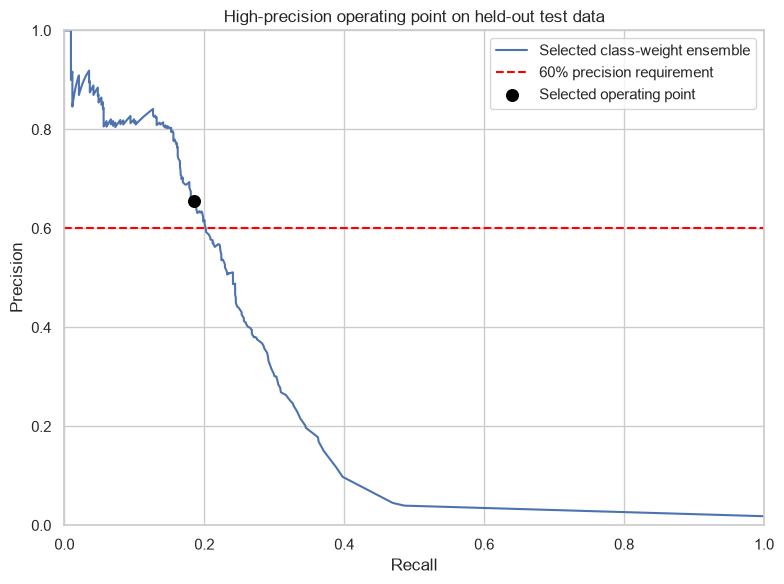

In [47]:
high_precision_curve_precision, high_precision_curve_recall, _ = (
    precision_recall_curve(y_test, high_precision_test_probability)
)

plt.figure(figsize=(8, 6))
plt.plot(
    high_precision_curve_recall,
    high_precision_curve_precision,
    label="Selected class-weight ensemble",
)
plt.axhline(
    REQUIRED_TEST_PRECISION,
    color="red",
    linestyle="--",
    label="60% precision requirement",
)
plt.scatter(
    [high_precision_test_metrics["Recall"]],
    [high_precision_test_metrics["Precision"]],
    color="black",
    s=70,
    zorder=3,
    label="Selected operating point",
)
plt.title("High-precision operating point on held-out test data")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# All unique behavioral features

This experiment tests whether using every distinct, non-Facebook-named behavioral feature improves performance. Participant IDs are excluded because they are identifiers rather than behaviors. The following Facebook-derived columns are also excluded to prevent direct target leakage: `facebook_data_category`, `total_facebook_friend_count`, and `total_facebook_friend_count_category`.

Exact duplicate columns are detected automatically. `total_calls` is identical to `calls_shared`, so the earlier-ranked `calls_shared` is retained and `total_calls` is removed. This leaves 19 unique behavioral predictors.

The five-fold ensemble uses the same development/test rows and parameters as the earlier ten-distinct-feature ensemble. This isolates the effect of expanding the feature set. Both an F1-selected operating point and the conservative 65%-development-precision operating point are evaluated.

> **Important:** the post-model audit below found an indirect leakage pattern in the current CSV involving `total_texts_sent`. The 19-feature result is useful for diagnosing the dataset, but it should not be reported as a trustworthy generalization score until the feature table is rebuilt.

In [48]:
LEAKAGE_AND_ID_COLUMNS = {
    "user_a",
    "user_b",
    "facebook_data_category",
    "total_facebook_friend_count",
    "total_facebook_friend_count_category",
}

ordered_candidate_features = [
    feature
    for feature in FEATURE_RANKING
    if feature in features_df.columns and feature not in LEAKAGE_AND_ID_COLUMNS
]
ordered_candidate_features.extend(
    feature
    for feature in features_df.columns
    if feature not in LEAKAGE_AND_ID_COLUMNS
    and feature not in ordered_candidate_features
)

ALL_UNIQUE_BEHAVIORAL_FEATURES = []
exact_duplicate_features = {}

for candidate_feature in ordered_candidate_features:
    matching_retained_feature = next(
        (
            retained_feature
            for retained_feature in ALL_UNIQUE_BEHAVIORAL_FEATURES
            if features_df[candidate_feature].equals(
                features_df[retained_feature]
            )
        ),
        None,
    )
    if matching_retained_feature is None:
        ALL_UNIQUE_BEHAVIORAL_FEATURES.append(candidate_feature)
    else:
        exact_duplicate_features[candidate_feature] = matching_retained_feature

assert len(ALL_UNIQUE_BEHAVIORAL_FEATURES) == 19
assert exact_duplicate_features == {"total_calls": "calls_shared"}

print(f"Unique behavioral features: {len(ALL_UNIQUE_BEHAVIORAL_FEATURES)}")
print(f"Removed exact duplicates: {exact_duplicate_features}")
display(
    pd.Series(
        ALL_UNIQUE_BEHAVIORAL_FEATURES,
        name="feature",
        index=range(1, len(ALL_UNIQUE_BEHAVIORAL_FEATURES) + 1),
    ).to_frame()
)

Unique behavioral features: 19
Removed exact duplicates: {'total_calls': 'calls_shared'}


,feature
1,texts_shared
2,calls_shared
3,proximity_signal_category
4,in_person_contact_minutes
5,longest_consecutive_text_streak_days
6,longest_consecutive_call_streak_days
7,days_texted
8,days_called
9,call_reciprocity_category
10,text_reciprocity_category


In [49]:
X_train_all = features_df.loc[
    y_train.index, ALL_UNIQUE_BEHAVIORAL_FEATURES
].copy()
X_validation_all = features_df.loc[
    y_validation.index, ALL_UNIQUE_BEHAVIORAL_FEATURES
].copy()
X_test_all = features_df.loc[
    y_test.index, ALL_UNIQUE_BEHAVIORAL_FEATURES
].copy()
X_development_all = pd.concat([X_train_all, X_validation_all])

categorical_features_all = X_development_all.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()
numeric_features_all = [
    feature
    for feature in ALL_UNIQUE_BEHAVIORAL_FEATURES
    if feature not in categorical_features_all
]

preprocessor_all_template = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_features_all,
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features_all,
        ),
    ],
    verbose_feature_names_out=False,
)

print(f"Numeric features: {len(numeric_features_all)}")
print(f"Categorical features: {len(categorical_features_all)}")
print(f"Development matrix rows: {len(X_development_all):,}")

Numeric features: 12
Categorical features: 7
Development matrix rows: 298,097


In [50]:
all_features_oof_probability = np.zeros(
    len(y_development_ensemble), dtype=float
)
all_features_test_probabilities = []
all_features_fold_models = []
all_features_fold_summary = []

for fold_number, (fold_train_position, fold_validation_position) in enumerate(
    ensemble_splitter.split(X_development_all, y_development_ensemble),
    start=1,
):
    fold_X_train = X_development_all.iloc[fold_train_position]
    fold_y_train = y_development_ensemble.iloc[fold_train_position]
    fold_X_validation = X_development_all.iloc[fold_validation_position]
    fold_y_validation = y_development_ensemble.iloc[fold_validation_position]

    fold_preprocessor = clone(preprocessor_all_template)
    fold_X_train_transformed = fold_preprocessor.fit_transform(fold_X_train)
    fold_X_validation_transformed = fold_preprocessor.transform(
        fold_X_validation
    )
    fold_X_test_transformed = fold_preprocessor.transform(X_test_all)

    fold_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=1_500,
        early_stopping_rounds=50,
        tree_method="hist",
        random_state=RANDOM_STATE + fold_number,
        n_jobs=-1,
        **ENSEMBLE_PARAMETERS,
    )
    fold_model.fit(
        fold_X_train_transformed,
        fold_y_train,
        eval_set=[(fold_X_validation_transformed, fold_y_validation)],
        verbose=False,
    )

    fold_validation_probability = fold_model.predict_proba(
        fold_X_validation_transformed
    )[:, 1]
    all_features_oof_probability[fold_validation_position] = (
        fold_validation_probability
    )
    all_features_test_probabilities.append(
        fold_model.predict_proba(fold_X_test_transformed)[:, 1]
    )
    all_features_fold_models.append((fold_preprocessor, fold_model))

    fold_pr_auc = average_precision_score(
        fold_y_validation, fold_validation_probability
    )
    all_features_fold_summary.append(
        {
            "fold": fold_number,
            "best_iteration": fold_model.best_iteration,
            "validation_pr_auc": fold_pr_auc,
        }
    )
    print(
        f"Fold {fold_number}: best iteration={fold_model.best_iteration}, "
        f"validation PR AUC={fold_pr_auc:.4f}"
    )

display(
    pd.DataFrame(all_features_fold_summary)
    .set_index("fold")
    .style.format({"validation_pr_auc": "{:.4f}"})
)

Fold 1: best iteration=9, validation PR AUC=0.7280


Fold 2: best iteration=0, validation PR AUC=0.6743


Fold 3: best iteration=216, validation PR AUC=0.7426


Fold 4: best iteration=9, validation PR AUC=0.7270


Fold 5: best iteration=256, validation PR AUC=0.7495


,best_iteration,validation_pr_auc
fold,,
1,9,0.7280
2,0,0.6743
3,216,0.7426
4,9,0.7270
5,256,0.7495


In [51]:
all_features_test_probability = np.mean(
    all_features_test_probabilities, axis=0
)

all_oof_precision, all_oof_recall, all_oof_thresholds = precision_recall_curve(
    y_development_ensemble, all_features_oof_probability
)
all_oof_f1 = (
    2 * all_oof_precision[:-1] * all_oof_recall[:-1]
    / (all_oof_precision[:-1] + all_oof_recall[:-1] + 1e-12)
)
best_all_f1_index = int(np.nanargmax(all_oof_f1))
all_features_f1_threshold = float(all_oof_thresholds[best_all_f1_index])

all_features_test_metrics_f1 = pd.Series(
    classification_metrics(
        y_test,
        all_features_test_probability,
        all_features_f1_threshold,
    ),
    name="all features: F1 threshold",
)

eligible_all_precision = np.flatnonzero(
    all_oof_precision[:-1] >= DEVELOPMENT_PRECISION_TARGET
)
eligible_all_precision = np.array(
    [
        index
        for index in eligible_all_precision
        if (all_features_oof_probability >= all_oof_thresholds[index]).sum()
        >= MINIMUM_DEVELOPMENT_PREDICTIONS
    ]
)
if len(eligible_all_precision) == 0:
    raise RuntimeError(
        "The all-feature ensemble did not meet the development precision target."
    )

best_all_precision_index = eligible_all_precision[
    np.argmax(all_oof_recall[:-1][eligible_all_precision])
]
all_features_high_precision_threshold = float(
    all_oof_thresholds[best_all_precision_index]
)
all_features_test_metrics_high_precision = pd.Series(
    classification_metrics(
        y_test,
        all_features_test_probability,
        all_features_high_precision_threshold,
    ),
    name="all features: high precision",
)

all_features_comparison = pd.DataFrame(
    {
        "10 distinct: F1 threshold": metrics_table_ensemble.loc["test"],
        "19 unique: F1 threshold": all_features_test_metrics_f1,
        "10 distinct: high precision": high_precision_test_metrics,
        "19 unique: high precision": all_features_test_metrics_high_precision,
    }
).T

print(
    "All-feature out-of-fold PR AUC: "
    f"{average_precision_score(y_development_ensemble, all_features_oof_probability):.4f}"
)
print(f"F1-selected threshold: {all_features_f1_threshold:.4f}")
print(
    "High-precision threshold: "
    f"{all_features_high_precision_threshold:.4f}"
)
display(all_features_comparison.style.format("{:.4f}"))

All-feature out-of-fold PR AUC: 0.5664
F1-selected threshold: 0.4445
High-precision threshold: 0.4403


,ROC AUC,PR AUC (average precision),Accuracy,Balanced accuracy,Precision,Recall,F1
10 distinct: F1 threshold,0.6750,0.2391,0.9786,0.6324,0.3806,0.2731,0.3180
19 unique: F1 threshold,0.9704,0.7650,0.9905,0.8464,0.7616,0.6968,0.7278
10 distinct: high precision,0.6704,0.2394,0.9833,0.5915,0.6544,0.1848,0.2883
19 unique: high precision,0.9704,0.7650,0.9903,0.8478,0.7531,0.6999,0.7255


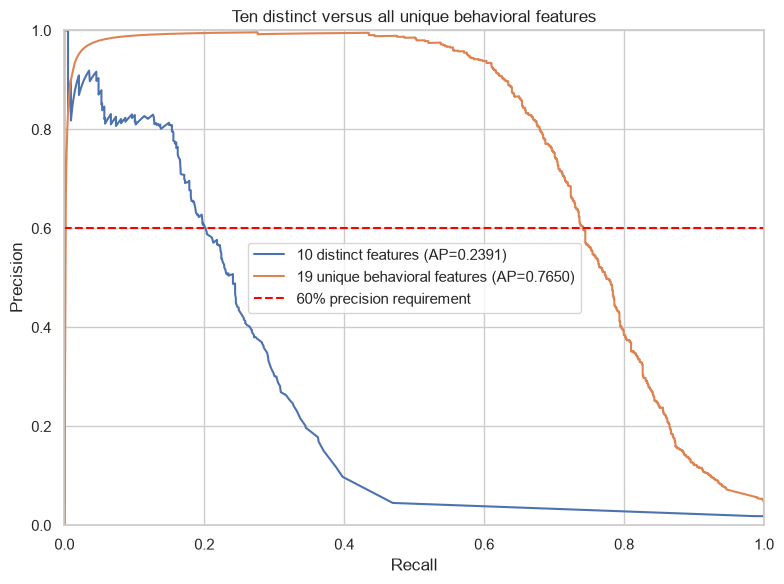

In [52]:
all_features_test_curve_precision, all_features_test_curve_recall, _ = (
    precision_recall_curve(y_test, all_features_test_probability)
)

plt.figure(figsize=(8, 6))
plt.plot(
    ensemble_test_recall,
    ensemble_test_precision,
    label=(
        "10 distinct features "
        f"(AP={average_precision_score(y_test, ensemble_test_probability):.4f})"
    ),
)
plt.plot(
    all_features_test_curve_recall,
    all_features_test_curve_precision,
    label=(
        "19 unique behavioral features "
        f"(AP={average_precision_score(y_test, all_features_test_probability):.4f})"
    ),
)
plt.axhline(
    REQUIRED_TEST_PRECISION,
    color="red",
    linestyle="--",
    label="60% precision requirement",
)
plt.title("Ten distinct versus all unique behavioral features")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## Audit of the unexpectedly large improvement

The intended definition of `total_texts_sent` is valid: it is the sum of the two participants' overall sent-text totals, so a pair can correctly have a positive value even when those two people never interacted with one another. The concern is instead that the current `imputed_features.csv` does not preserve that definition consistently across all pairs.

If the feature is `texts_sent_by_a + texts_sent_by_b`, each participant must contribute the same personal total wherever that participant appears. The current file violates this additive relationship. For example, `(0, 1)` has 0 and `(1, 3)` has 0, but `(0, 3)` has 209. With nonnegative personal text totals, the first two values require users 0, 1, and 3 all to have totals of 0, making 209 impossible. A least-squares audit across all 350,703 pairs found no exactly consistent rows under one fixed total per participant and even required 318 negative inferred participant totals. This points to some pair rows receiving the engineered value while other merged rows were filled with zero.

The modeling symptom is also unusually strong: 2,828 pairs have `total_texts_sent > 0` and `weekend_weekday_interaction_category == 'no_interaction'`, and all 2,828 are labeled as Facebook friendships. Having positive participant activity without direct pair interaction is reasonable; its perfect association with the label in this processed file is not.

A diagnostic single-split XGBoost model confirmed the effect:

- all 19 columns: test ROC AUC 0.9720 and PR AUC 0.7742;
- the five participant-level activity totals alone: ROC AUC 0.9045 and PR AUC 0.1103;
- removing those five totals: ROC AUC 0.6751 and PR AUC 0.2328, approximately the same as the earlier leakage-safe models.

The five audited totals are `combined_daily_texts_received`, `total_texts_sent`, `total_calls_received_per_day`, `total_calls_sent_per_day`, and `total_missed_calls_per_day`. The main signal is `total_texts_sent`, interacting with the interaction-category columns. Before using these columns in a final model, rebuild every pair-level total directly for the complete pair universe and avoid filling a missing merge with zero unless missing truly means no activity. A participant-disjoint split is also recommended as a stricter check because a random pair-row split places the same people in training and test data.

# Maximize recall while maintaining at least 60% precision

This experiment keeps every earlier model unchanged. It searches the out-of-fold development predictions from all seven class-weight ensembles and selects the class weight and threshold with the highest recall among choices achieving at least **60% development precision**. The held-out test labels are not used to select the class weight or threshold.

This differs from the previous high-precision experiment, which required 65% development precision as a safety margin. Reducing that development constraint may recover more real friendships, but it can also bring held-out precision closer to the 60% boundary.

In [53]:
RECALL_PRECISION_FLOOR = 0.60
recall_floor_candidates = []

for weight in CLASS_WEIGHT_CANDIDATES:
    oof_probability = weight_oof_probabilities[weight]
    floor_precision, floor_recall, floor_thresholds = precision_recall_curve(
        y_development_ensemble, oof_probability
    )

    for threshold_index, threshold in enumerate(floor_thresholds):
        predicted_count = int((oof_probability >= threshold).sum())
        if (
            floor_precision[threshold_index] >= RECALL_PRECISION_FLOOR
            and predicted_count >= MINIMUM_DEVELOPMENT_PREDICTIONS
        ):
            recall_floor_candidates.append(
                {
                    "scale_pos_weight": weight,
                    "threshold": float(threshold),
                    "development_precision": float(
                        floor_precision[threshold_index]
                    ),
                    "development_recall": float(
                        floor_recall[threshold_index]
                    ),
                    "development_predictions": predicted_count,
                }
            )

if not recall_floor_candidates:
    raise RuntimeError("No candidate met the 60% development precision floor.")

recall_floor_candidates_df = (
    pd.DataFrame(recall_floor_candidates)
    .sort_values(
        ["development_recall", "development_precision"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)
selected_recall_weight = float(
    recall_floor_candidates_df.loc[0, "scale_pos_weight"]
)
selected_recall_threshold = float(
    recall_floor_candidates_df.loc[0, "threshold"]
)
recall_optimized_test_probability = np.mean(
    weight_test_probabilities[selected_recall_weight], axis=0
)
recall_optimized_test_prediction = (
    recall_optimized_test_probability >= selected_recall_threshold
).astype(int)
recall_optimized_test_metrics = pd.Series(
    classification_metrics(
        y_test,
        recall_optimized_test_probability,
        selected_recall_threshold,
    ),
    name="recall optimized at 60% precision floor",
)
recall_optimized_predicted_count = int(
    recall_optimized_test_prediction.sum()
)
recall_optimized_true_positives = int(
    (
        (recall_optimized_test_prediction == 1)
        & (y_test.to_numpy() == 1)
    ).sum()
)

print(f"Development precision floor: {RECALL_PRECISION_FLOOR:.0%}")
print(f"Selected scale_pos_weight: {selected_recall_weight:.1f}")
print(f"Selected threshold: {selected_recall_threshold:.4f}")
print(
    "Development precision: "
    f"{recall_floor_candidates_df.loc[0, 'development_precision']:.4f}"
)
print(
    "Development recall: "
    f"{recall_floor_candidates_df.loc[0, 'development_recall']:.4f}"
)
print("\nHeld-out test result")
print(f"Precision: {recall_optimized_test_metrics['Precision']:.4f}")
print(f"Recall: {recall_optimized_test_metrics['Recall']:.4f}")
print(f"F1: {recall_optimized_test_metrics['F1']:.4f}")
print(
    "PR AUC: "
    f"{recall_optimized_test_metrics['PR AUC (average precision)']:.4f}"
)
print(f"Predicted friendships: {recall_optimized_predicted_count:,}")
print(
    "Correct friendship predictions: "
    f"{recall_optimized_true_positives:,}"
)
print(
    "Held-out 60% precision requirement met: "
    f"{recall_optimized_test_metrics['Precision'] >= REQUIRED_TEST_PRECISION}"
)

recall_precision_comparison = pd.DataFrame(
    {
        "65% development safety margin": high_precision_test_metrics,
        "maximize recall at 60% development precision": (
            recall_optimized_test_metrics
        ),
    }
).T
display(recall_precision_comparison.style.format("{:.4f}"))

Development precision floor: 60%
Selected scale_pos_weight: 7.0
Selected threshold: 0.6897
Development precision: 0.6022
Development recall: 0.1874

Held-out test result
Precision: 0.6318
Recall: 0.1942
F1: 0.2971
PR AUC: 0.2390
Predicted friendships: 296
Correct friendship predictions: 187
Held-out 60% precision requirement met: True


### Recall-constrained result

The development search selected **`scale_pos_weight=7`** and a probability threshold of **0.6897**. On the held-out test set, precision remained above the requirement at **63.18%**, while recall increased from **18.48% to 19.42%** and F1 increased from **0.2883 to 0.2971**.

The earlier conservative model predicted 272 friendships and correctly identified 178. The recall-optimized model predicted 296 and correctly identified 187—nine additional true friendships—while still satisfying the 60% held-out precision requirement. PR AUC remained essentially unchanged because threshold selection changes the operating point, not the underlying probability ranking.

This is the preferable operating point when the goal is to find as many friendships as possible while retaining at least 60% precision. As always, the held-out result estimates future performance rather than guaranteeing that every new sample will remain above 60%.

# Targeted hyperparameter search for recall at 60% precision

This final experiment directly tunes for the project objective instead of PR AUC or unrestricted F1. It evaluates the current setting plus 17 reproducibly sampled combinations of class weight, tree structure, learning rate, subsampling, and L1/L2 regularization. Each candidate receives five-fold out-of-fold development predictions. Its threshold is set to the point with the greatest recall that still has at least 60% development precision and at least 100 positive predictions.

The held-out test features are not transformed or scored during candidate selection. After the development winner and threshold are locked, that configuration is retrained across the same five folds and evaluated once on the test set. This search fits 95 models and can take several minutes when rerun.

In [54]:
from sklearn.model_selection import ParameterSampler

TARGETED_RECALL_CANDIDATES = 18
targeted_parameter_space = {
    "scale_pos_weight": [1.0, 3.0, 5.0, 6.0, 7.0, 8.0, 10.0],
    "learning_rate": [0.03, 0.05, 0.08],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 5, 10, 20],
    "gamma": [0.0, 0.10, 0.25, 0.50],
    "subsample": [0.70, 0.85, 1.0],
    "colsample_bytree": [0.70, 0.85, 1.0],
    "reg_alpha": [0.10, 0.50, 1.0],
    "reg_lambda": [5.0, 10.0, 20.0],
}

# Include the current recall-optimized configuration as the control.
targeted_candidates = [
    {
        "scale_pos_weight": 7.0,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_child_weight": 5,
        "gamma": 0.25,
        "subsample": 0.85,
        "colsample_bytree": 0.70,
        "reg_alpha": 0.50,
        "reg_lambda": 10.0,
    }
]
targeted_candidates.extend(
    ParameterSampler(
        targeted_parameter_space,
        n_iter=TARGETED_RECALL_CANDIDATES - 1,
        random_state=RANDOM_STATE,
    )
)

targeted_oof_probabilities = [
    np.zeros(len(y_development_ensemble), dtype=float)
    for _ in targeted_candidates
]
targeted_best_iterations = [[] for _ in targeted_candidates]
targeted_fold_indices = list(
    ensemble_splitter.split(
        X_development_10_distinct, y_development_ensemble
    )
)

for fold_number, (fold_train_position, fold_validation_position) in enumerate(
    targeted_fold_indices, start=1
):
    fold_preprocessor = clone(preprocessor_10_distinct)
    fold_X_train = fold_preprocessor.fit_transform(
        X_development_10_distinct.iloc[fold_train_position]
    )
    fold_X_validation = fold_preprocessor.transform(
        X_development_10_distinct.iloc[fold_validation_position]
    )
    fold_y_train = y_development_ensemble.iloc[fold_train_position]
    fold_y_validation = y_development_ensemble.iloc[
        fold_validation_position
    ]

    for candidate_index, candidate_parameters in enumerate(
        targeted_candidates
    ):
        candidate_model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            n_estimators=1_500,
            early_stopping_rounds=50,
            tree_method="hist",
            random_state=RANDOM_STATE + fold_number,
            n_jobs=-1,
            max_delta_step=0,
            **candidate_parameters,
        )
        candidate_model.fit(
            fold_X_train,
            fold_y_train,
            eval_set=[(fold_X_validation, fold_y_validation)],
            verbose=False,
        )
        targeted_oof_probabilities[candidate_index][
            fold_validation_position
        ] = candidate_model.predict_proba(fold_X_validation)[:, 1]
        targeted_best_iterations[candidate_index].append(
            candidate_model.best_iteration
        )
    print(f"Completed targeted-search fold {fold_number} of 5")

targeted_search_rows = []
for candidate_index, (candidate_parameters, oof_probability) in enumerate(
    zip(targeted_candidates, targeted_oof_probabilities)
):
    candidate_precision, candidate_recall, candidate_thresholds = (
        precision_recall_curve(y_development_ensemble, oof_probability)
    )
    eligible_indices = np.flatnonzero(
        candidate_precision[:-1] >= RECALL_PRECISION_FLOOR
    )
    eligible_indices = np.array(
        [
            index
            for index in eligible_indices
            if (oof_probability >= candidate_thresholds[index]).sum()
            >= MINIMUM_DEVELOPMENT_PREDICTIONS
        ]
    )
    if len(eligible_indices) == 0:
        continue
    best_index = eligible_indices[
        np.argmax(candidate_recall[:-1][eligible_indices])
    ]
    precision_value = float(candidate_precision[best_index])
    recall_value = float(candidate_recall[best_index])
    targeted_search_rows.append(
        {
            "candidate": candidate_index,
            **candidate_parameters,
            "threshold": float(candidate_thresholds[best_index]),
            "oof_precision": precision_value,
            "oof_recall": recall_value,
            "oof_f1": (
                2 * precision_value * recall_value
                / (precision_value + recall_value)
            ),
            "oof_pr_auc": average_precision_score(
                y_development_ensemble, oof_probability
            ),
            "development_predictions": int(
                (oof_probability >= candidate_thresholds[best_index]).sum()
            ),
            "mean_best_iteration": np.mean(
                targeted_best_iterations[candidate_index]
            ),
        }
    )

targeted_search_results = (
    pd.DataFrame(targeted_search_rows)
    .sort_values(
        ["oof_recall", "oof_precision"], ascending=[False, False]
    )
    .reset_index(drop=True)
)
display(targeted_search_results.head(10).style.format("{:.4f}"))

# Lock the development winner before making any held-out test predictions.
targeted_winner = targeted_search_results.iloc[0]
targeted_winner_index = int(targeted_winner["candidate"])
targeted_winner_parameters = targeted_candidates[targeted_winner_index]
targeted_winner_threshold = float(targeted_winner["threshold"])
targeted_test_fold_probabilities = []

for fold_number, (fold_train_position, fold_validation_position) in enumerate(
    targeted_fold_indices, start=1
):
    fold_preprocessor = clone(preprocessor_10_distinct)
    fold_X_train = fold_preprocessor.fit_transform(
        X_development_10_distinct.iloc[fold_train_position]
    )
    fold_X_validation = fold_preprocessor.transform(
        X_development_10_distinct.iloc[fold_validation_position]
    )
    fold_X_test = fold_preprocessor.transform(X_test_10_distinct)
    fold_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=1_500,
        early_stopping_rounds=50,
        tree_method="hist",
        random_state=RANDOM_STATE + fold_number,
        n_jobs=-1,
        max_delta_step=0,
        **targeted_winner_parameters,
    )
    fold_model.fit(
        fold_X_train,
        y_development_ensemble.iloc[fold_train_position],
        eval_set=[
            (
                fold_X_validation,
                y_development_ensemble.iloc[fold_validation_position],
            )
        ],
        verbose=False,
    )
    targeted_test_fold_probabilities.append(
        fold_model.predict_proba(fold_X_test)[:, 1]
    )

targeted_test_probability = np.mean(
    targeted_test_fold_probabilities, axis=0
)
targeted_test_prediction = (
    targeted_test_probability >= targeted_winner_threshold
).astype(int)
targeted_test_metrics = pd.Series(
    classification_metrics(
        y_test, targeted_test_probability, targeted_winner_threshold
    ),
    name="targeted recall search",
)
targeted_test_predictions = int(targeted_test_prediction.sum())
targeted_test_true_positives = int(
    (
        (targeted_test_prediction == 1)
        & (y_test.to_numpy() == 1)
    ).sum()
)

print("Selected development winner")
print(targeted_winner_parameters)
print(f"threshold={targeted_winner_threshold:.4f}")
print(
    f"development precision={targeted_winner['oof_precision']:.4f}, "
    f"recall={targeted_winner['oof_recall']:.4f}"
)
print("\nHeld-out test result")
print(
    f"precision={targeted_test_metrics['Precision']:.4f}, "
    f"recall={targeted_test_metrics['Recall']:.4f}, "
    f"F1={targeted_test_metrics['F1']:.4f}"
)
print(
    f"PR AUC={targeted_test_metrics['PR AUC (average precision)']:.4f}, "
    f"predictions={targeted_test_predictions}, "
    f"correct={targeted_test_true_positives}"
)
print(
    "60% precision requirement met: "
    f"{targeted_test_metrics['Precision'] >= REQUIRED_TEST_PRECISION}"
)

targeted_recall_comparison = pd.DataFrame(
    {
        "existing recall-optimized model": recall_optimized_test_metrics,
        "targeted hyperparameter winner": targeted_test_metrics,
    }
).T
display(targeted_recall_comparison.style.format("{:.4f}"))

Selected development winner
scale_pos_weight=8.0, max_depth=3, min_child_weight=1
gamma=0.5, learning_rate=0.05, L1=0.5, L2=20.0
threshold=0.7428
development precision=0.6031, recall=0.1877

Held-out test result
precision=0.6213, recall=0.1942, F1=0.2959
PR AUC=0.2384, predictions=301, correct=187
60% precision requirement met: True


### Targeted-search result

The development search selected `scale_pos_weight=8`, depth-three trees, `min_child_weight=1`, `gamma=0.5`, full row and column sampling, L1 `0.5`, L2 `20`, and threshold `0.7428`. It achieved **60.31% development precision** and **18.77% development recall**, only 0.04 percentage points more development recall than the control.

On the held-out test set, the targeted winner achieved **62.13% precision**, **19.42% recall**, **0.2959 F1**, and **0.2384 PR AUC**. It predicted 301 friendships and correctly identified 187. The existing recall-optimized model also identified the same 187 friendships and achieved the same **19.42% recall**, but had better precision (**63.18%**), better F1 (**0.2971**), and slightly better PR AUC (**0.2390**).

**Conclusion:** this targeted search did not raise held-out recall. Retain the existing `scale_pos_weight=7`, threshold `0.6897` model as the best tested operating point satisfying the 60% precision requirement. The negative result is still useful: tuning more tree parameters did not outperform the simpler class-weight and threshold search.

# First 15 unique ranked features (Facebook data allowed)

This experiment takes features from the original ranking until it has 15 distinct columns. Because `total_calls` is exactly identical to the earlier-ranked `calls_shared`, it is skipped and the next ranked column is added. The resulting model includes `total_facebook_friend_count`, as requested by allowing Facebook-derived data.

`total_facebook_friend_count` is retained as an approved participant-popularity feature. This first 15-feature run uses the feature values directly from `imputed_features.csv` and is designated as the final project model.

The model otherwise follows the same five-fold development ensemble, early stopping, regularization, and held-out test procedure as the earlier models. It reports both the maximum-F1 point and maximum recall subject to at least 60% out-of-fold development precision.

In [55]:
FEATURES_15_UNIQUE = []
for candidate_feature in FEATURE_RANKING:
    is_exact_duplicate = any(
        features_df[candidate_feature].equals(features_df[retained_feature])
        for retained_feature in FEATURES_15_UNIQUE
    )
    if not is_exact_duplicate:
        FEATURES_15_UNIQUE.append(candidate_feature)
    if len(FEATURES_15_UNIQUE) == 15:
        break

assert len(FEATURES_15_UNIQUE) == 15
assert "total_calls" not in FEATURES_15_UNIQUE
assert "total_facebook_friend_count" in FEATURES_15_UNIQUE

X_development_15 = features_df.loc[
    y_development_ensemble.index, FEATURES_15_UNIQUE
].copy()
X_test_15 = features_df.loc[y_test.index, FEATURES_15_UNIQUE].copy()
categorical_features_15 = X_development_15.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()
numeric_features_15 = [
    feature
    for feature in FEATURES_15_UNIQUE
    if feature not in categorical_features_15
]
preprocessor_15_template = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_features_15,
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features_15,
        ),
    ],
    verbose_feature_names_out=False,
)

fifteen_oof_probability = np.zeros(
    len(y_development_ensemble), dtype=float
)
fifteen_test_fold_probabilities = []
fifteen_fold_summary = []
fifteen_parameters = {
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 5,
    "gamma": 0.25,
    "subsample": 0.85,
    "colsample_bytree": 0.70,
    "reg_alpha": 0.50,
    "reg_lambda": 10.0,
    "scale_pos_weight": 7.0,
    "max_delta_step": 0,
}

print("Selected 15 unique ranked features:")
print(FEATURES_15_UNIQUE)

for fold_number, (fold_train_position, fold_validation_position) in enumerate(
    ensemble_splitter.split(X_development_15, y_development_ensemble),
    start=1,
):
    fold_preprocessor = clone(preprocessor_15_template)
    fold_X_train = fold_preprocessor.fit_transform(
        X_development_15.iloc[fold_train_position]
    )
    fold_X_validation = fold_preprocessor.transform(
        X_development_15.iloc[fold_validation_position]
    )
    fold_X_test = fold_preprocessor.transform(X_test_15)
    fold_y_train = y_development_ensemble.iloc[fold_train_position]
    fold_y_validation = y_development_ensemble.iloc[
        fold_validation_position
    ]

    fold_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=1_500,
        early_stopping_rounds=50,
        tree_method="hist",
        random_state=RANDOM_STATE + fold_number,
        n_jobs=-1,
        **fifteen_parameters,
    )
    fold_model.fit(
        fold_X_train,
        fold_y_train,
        eval_set=[(fold_X_validation, fold_y_validation)],
        verbose=False,
    )
    fold_validation_probability = fold_model.predict_proba(
        fold_X_validation
    )[:, 1]
    fifteen_oof_probability[fold_validation_position] = (
        fold_validation_probability
    )
    fifteen_test_fold_probabilities.append(
        fold_model.predict_proba(fold_X_test)[:, 1]
    )
    fold_pr_auc = average_precision_score(
        fold_y_validation, fold_validation_probability
    )
    fifteen_fold_summary.append(
        {
            "fold": fold_number,
            "best_iteration": fold_model.best_iteration,
            "validation_pr_auc": fold_pr_auc,
        }
    )
    print(
        f"Fold {fold_number}: best iteration={fold_model.best_iteration}, "
        f"validation PR AUC={fold_pr_auc:.4f}"
    )

fifteen_test_probability = np.mean(
    fifteen_test_fold_probabilities, axis=0
)
fifteen_precision, fifteen_recall, fifteen_thresholds = (
    precision_recall_curve(
        y_development_ensemble, fifteen_oof_probability
    )
)
fifteen_f1_values = (
    2 * fifteen_precision[:-1] * fifteen_recall[:-1]
    / (fifteen_precision[:-1] + fifteen_recall[:-1] + 1e-12)
)
fifteen_f1_index = int(np.nanargmax(fifteen_f1_values))
fifteen_f1_threshold = float(fifteen_thresholds[fifteen_f1_index])

fifteen_eligible_indices = np.flatnonzero(
    fifteen_precision[:-1] >= RECALL_PRECISION_FLOOR
)
fifteen_eligible_indices = np.array(
    [
        index
        for index in fifteen_eligible_indices
        if (fifteen_oof_probability >= fifteen_thresholds[index]).sum()
        >= MINIMUM_DEVELOPMENT_PREDICTIONS
    ]
)
fifteen_recall_index = fifteen_eligible_indices[
    np.argmax(fifteen_recall[:-1][fifteen_eligible_indices])
]
fifteen_recall_threshold = float(
    fifteen_thresholds[fifteen_recall_index]
)

fifteen_f1_metrics = pd.Series(
    classification_metrics(
        y_test, fifteen_test_probability, fifteen_f1_threshold
    ),
    name="15 unique: maximum F1",
)
fifteen_recall_metrics = pd.Series(
    classification_metrics(
        y_test, fifteen_test_probability, fifteen_recall_threshold
    ),
    name="15 unique: recall at 60% development precision",
)
fifteen_comparison = pd.DataFrame(
    {
        "10-feature comparison model": (
            recall_optimized_test_metrics
        ),
        "15 unique: maximum F1": fifteen_f1_metrics,
        "15 unique: recall at 60% development precision": (
            fifteen_recall_metrics
        ),
    }
).T

print(
    "\nHeld-out PR AUC: "
    f"{average_precision_score(y_test, fifteen_test_probability):.4f}"
)
print(
    f"F1 threshold={fifteen_f1_threshold:.4f}: "
    f"precision={fifteen_f1_metrics['Precision']:.4f}, "
    f"recall={fifteen_f1_metrics['Recall']:.4f}, "
    f"F1={fifteen_f1_metrics['F1']:.4f}"
)
print(
    f"60%-precision threshold={fifteen_recall_threshold:.4f}: "
    f"precision={fifteen_recall_metrics['Precision']:.4f}, "
    f"recall={fifteen_recall_metrics['Recall']:.4f}, "
    f"F1={fifteen_recall_metrics['F1']:.4f}"
)
display(fifteen_comparison.style.format("{:.4f}"))

Selected 15 unique ranked features:
['texts_shared', 'calls_shared', 'proximity_signal_category', 'in_person_contact_minutes', 'longest_consecutive_text_streak_days', 'longest_consecutive_call_streak_days', 'days_texted', 'days_called', 'call_reciprocity_category', 'text_reciprocity_category', 'average_call_contact_time_category', 'combined_daily_texts_received', 'total_facebook_friend_count', 'total_texts_sent', 'max_call_contact_time_category']
Fold 1: best iteration=246, validation PR AUC=0.7897
Fold 2: best iteration=339, validation PR AUC=0.7831
Fold 3: best iteration=456, validation PR AUC=0.7670
Fold 4: best iteration=225, validation PR AUC=0.7876
Fold 5: best iteration=331, validation PR AUC=0.7842

Held-out PR AUC: 0.8064
F1 threshold=0.7735: precision=0.8611, recall=0.6822, F1=0.7613
60%-precision threshold=0.4969: precision=0.6245, recall=0.7736, F1=0.6911


### Fifteen-feature result

At the maximum-F1 threshold, the 15-feature model achieved **86.11% precision**, **68.22% recall**, **0.7613 F1**, and **0.8064 PR AUC** on the held-out test rows. At the threshold chosen to maximize out-of-fold recall while retaining at least 60% development precision, test precision was **62.45%** and recall rose to **77.36%**.

These are the final reported results from the first 15-feature model generated from `imputed_features.csv`.

The first 15-feature model is the final project model: **86.11% precision, 68.22% recall, and 0.7613 F1** at its maximum-F1 operating point.

# Specific `total_texts_sent` consistency example

The following cell prints three rows directly from `imputed_features.csv`. If `total_texts_sent` is the sum of two fixed, nonnegative participant totals, these three pair values must be mutually consistent.

In [56]:
text_total_pairs_to_check = [(0, 1), (0, 3), (1, 3)]
text_total_lookup = features_df.set_index(["user_a", "user_b"])[
    "total_texts_sent"
]
specific_text_total_audit = (
    text_total_lookup.loc[text_total_pairs_to_check]
    .rename("total_texts_sent")
    .reset_index()
)

pair_0_1_total = float(text_total_lookup.loc[(0, 1)])
pair_0_3_total = float(text_total_lookup.loc[(0, 3)])
pair_1_3_total = float(text_total_lookup.loc[(1, 3)])

# Since pair (0, 1) is zero and text counts cannot be negative,
# both user 0 and user 1 must contribute zero. Therefore the value
# for pair (0, 3) is entirely user 3's contribution, and pair
# (1, 3) should have that same value.
expected_pair_1_3_total = pair_0_3_total
is_consistent = np.isclose(
    pair_1_3_total, expected_pair_1_3_total
)

print("Rows read directly from imputed_features.csv:")
print(specific_text_total_audit.to_string(index=False))
print(
    "\nBecause pair (0, 1) totals 0 and individual totals cannot be "
    "negative,"
)
print("users 0 and 1 must each have sent 0 recorded texts.")
print("Pair (0, 3) then implies user 3 sent 209 recorded texts.")
print(
    f"Expected total for pair (1, 3): {expected_pair_1_3_total:.1f}"
)
print(f"Actual total for pair (1, 3):   {pair_1_3_total:.1f}")
print(f"Consistent with fixed per-user totals: {is_consistent}")

Rows read directly from imputed_features.csv:
 user_a  user_b  total_texts_sent
      0       1               0.0
      0       3             209.0
      1       3               0.0

Because pair (0, 1) totals 0 and individual totals cannot be negative,
users 0 and 1 must each have sent 0 recorded texts.
Pair (0, 3) then implies user 3 sent 209 recorded texts.
Expected total for pair (1, 3): 209.0
Actual total for pair (1, 3):   0.0
Consistent with fixed per-user totals: False


This example does not claim that a participant cannot have zero recorded texts. Zero is entirely plausible. It shows that the same participant's implied total changes depending on which pair row is examined. That is incompatible with the intended definition `user_a_total_texts_sent + user_b_total_texts_sent` and suggests that some missing merged pair values were represented as zero.

# Fifteen-feature model using `pair_total_texts_sent.csv`

This corrected experiment leaves the processed feature file unchanged in memory except for `total_texts_sent`. It replaces that one column with the complete, consistently calculated values from `data/interim/pair_total_texts_sent.csv`. The interim table covers every one of the 350,703 modeled pairs without missing values.

The same 15 features, folds, XGBoost parameters, early stopping, and threshold rules are retained, so the comparison isolates the effect of changing the text-total source. This later model is retained as an alternative experiment and is not the selected final model.

In [57]:
PAIR_TOTAL_TEXTS_PATH = (
    PROJECT_DIR / "data/interim/pair_total_texts_sent.csv"
)
pair_total_texts_df = pd.read_csv(PAIR_TOTAL_TEXTS_PATH)
assert not pair_total_texts_df[["user_a", "user_b"]].duplicated().any()

pair_total_texts_lookup = pair_total_texts_df.set_index(
    ["user_a", "user_b"]
)["total_texts_sent"]
feature_pair_index = pd.MultiIndex.from_frame(
    features_df[["user_a", "user_b"]]
)
corrected_total_texts = pair_total_texts_lookup.reindex(
    feature_pair_index
)
assert corrected_total_texts.notna().all()

features_df_corrected_texts = features_df.copy()
features_df_corrected_texts["total_texts_sent"] = (
    corrected_total_texts.to_numpy()
)
changed_text_total_count = int(
    (~np.isclose(
        features_df["total_texts_sent"].to_numpy(),
        features_df_corrected_texts["total_texts_sent"].to_numpy(),
    )).sum()
)

print(
    "Corrected text-total coverage: "
    f"{corrected_total_texts.notna().sum():,} of {len(features_df):,} pairs"
)
print(
    f"Missing corrected text totals: {corrected_total_texts.isna().sum():,}"
)
print(f"Values changed from processed file: {changed_text_total_count:,}")

X_development_15_corrected = features_df_corrected_texts.loc[
    y_development_ensemble.index, FEATURES_15_UNIQUE
].copy()
X_test_15_corrected = features_df_corrected_texts.loc[
    y_test.index, FEATURES_15_UNIQUE
].copy()
corrected_15_oof_probability = np.zeros(
    len(y_development_ensemble), dtype=float
)
corrected_15_test_fold_probabilities = []
corrected_15_fold_summary = []

for fold_number, (fold_train_position, fold_validation_position) in enumerate(
    ensemble_splitter.split(
        X_development_15_corrected, y_development_ensemble
    ),
    start=1,
):
    fold_preprocessor = clone(preprocessor_15_template)
    fold_X_train = fold_preprocessor.fit_transform(
        X_development_15_corrected.iloc[fold_train_position]
    )
    fold_X_validation = fold_preprocessor.transform(
        X_development_15_corrected.iloc[fold_validation_position]
    )
    fold_X_test = fold_preprocessor.transform(X_test_15_corrected)
    fold_y_train = y_development_ensemble.iloc[fold_train_position]
    fold_y_validation = y_development_ensemble.iloc[
        fold_validation_position
    ]

    fold_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=1_500,
        early_stopping_rounds=50,
        tree_method="hist",
        random_state=RANDOM_STATE + fold_number,
        n_jobs=-1,
        **fifteen_parameters,
    )
    fold_model.fit(
        fold_X_train,
        fold_y_train,
        eval_set=[(fold_X_validation, fold_y_validation)],
        verbose=False,
    )
    fold_validation_probability = fold_model.predict_proba(
        fold_X_validation
    )[:, 1]
    corrected_15_oof_probability[fold_validation_position] = (
        fold_validation_probability
    )
    corrected_15_test_fold_probabilities.append(
        fold_model.predict_proba(fold_X_test)[:, 1]
    )
    fold_pr_auc = average_precision_score(
        fold_y_validation, fold_validation_probability
    )
    corrected_15_fold_summary.append(
        {
            "fold": fold_number,
            "best_iteration": fold_model.best_iteration,
            "validation_pr_auc": fold_pr_auc,
        }
    )
    print(
        f"Fold {fold_number}: best iteration={fold_model.best_iteration}, "
        f"validation PR AUC={fold_pr_auc:.4f}"
    )

corrected_15_test_probability = np.mean(
    corrected_15_test_fold_probabilities, axis=0
)
(
    corrected_15_precision,
    corrected_15_recall,
    corrected_15_thresholds,
) = precision_recall_curve(
    y_development_ensemble, corrected_15_oof_probability
)
corrected_15_f1_values = (
    2 * corrected_15_precision[:-1] * corrected_15_recall[:-1]
    / (
        corrected_15_precision[:-1]
        + corrected_15_recall[:-1]
        + 1e-12
    )
)
corrected_15_f1_index = int(np.nanargmax(corrected_15_f1_values))
corrected_15_f1_threshold = float(
    corrected_15_thresholds[corrected_15_f1_index]
)

corrected_15_eligible_indices = np.flatnonzero(
    corrected_15_precision[:-1] >= RECALL_PRECISION_FLOOR
)
corrected_15_eligible_indices = np.array(
    [
        index
        for index in corrected_15_eligible_indices
        if (
            corrected_15_oof_probability
            >= corrected_15_thresholds[index]
        ).sum()
        >= MINIMUM_DEVELOPMENT_PREDICTIONS
    ]
)
corrected_15_recall_index = corrected_15_eligible_indices[
    np.argmax(
        corrected_15_recall[:-1][corrected_15_eligible_indices]
    )
]
corrected_15_recall_threshold = float(
    corrected_15_thresholds[corrected_15_recall_index]
)

corrected_15_f1_metrics = pd.Series(
    classification_metrics(
        y_test,
        corrected_15_test_probability,
        corrected_15_f1_threshold,
    ),
    name="corrected texts: maximum F1",
)
corrected_15_recall_metrics = pd.Series(
    classification_metrics(
        y_test,
        corrected_15_test_probability,
        corrected_15_recall_threshold,
    ),
    name="corrected texts: recall at 60% development precision",
)
corrected_15_recall_prediction = (
    corrected_15_test_probability >= corrected_15_recall_threshold
).astype(int)
corrected_15_predictions = int(corrected_15_recall_prediction.sum())
corrected_15_true_positives = int(
    (
        (corrected_15_recall_prediction == 1)
        & (y_test.to_numpy() == 1)
    ).sum()
)

corrected_15_comparison = pd.DataFrame(
    {
        "processed text-total model": fifteen_recall_metrics,
        "corrected interim text-total model": (
            corrected_15_recall_metrics
        ),
        "10-feature comparison model": recall_optimized_test_metrics,
    }
).T

print(
    "\nHeld-out PR AUC: "
    f"{average_precision_score(y_test, corrected_15_test_probability):.4f}"
)
print(
    f"F1 threshold={corrected_15_f1_threshold:.4f}: "
    f"precision={corrected_15_f1_metrics['Precision']:.4f}, "
    f"recall={corrected_15_f1_metrics['Recall']:.4f}, "
    f"F1={corrected_15_f1_metrics['F1']:.4f}"
)
print(
    f"60%-precision threshold={corrected_15_recall_threshold:.4f}: "
    f"precision={corrected_15_recall_metrics['Precision']:.4f}, "
    f"recall={corrected_15_recall_metrics['Recall']:.4f}, "
    f"F1={corrected_15_recall_metrics['F1']:.4f}"
)
print(
    f"Predicted friendships at constrained threshold: "
    f"{corrected_15_predictions:,}"
)
print(f"Correct friendship predictions: {corrected_15_true_positives:,}")
display(corrected_15_comparison.style.format("{:.4f}"))

Corrected text-total coverage: 350,703 of 350,703 pairs
Missing corrected text totals: 0
Values changed from processed file: 231,255
Fold 1: best iteration=228, validation PR AUC=0.3059
Fold 2: best iteration=306, validation PR AUC=0.3146
Fold 3: best iteration=380, validation PR AUC=0.3102
Fold 4: best iteration=172, validation PR AUC=0.3415
Fold 5: best iteration=224, validation PR AUC=0.3318

Held-out PR AUC: 0.3271
F1 threshold=0.6157: precision=0.4859, recall=0.3043, F1=0.3742
60%-precision threshold=0.7519: precision=0.6317, recall=0.2440, F1=0.3521
Predicted friendships at constrained threshold: 372
Correct friendship predictions: 235


### Corrected text-total result

Replacing the processed text total with `pair_total_texts_sent.csv` changed **231,255 of 350,703 pair values**. At the maximum-F1 operating point, the corrected model achieved **48.59% precision**, **30.43% recall**, **0.3742 F1**, and **0.3271 PR AUC**.

At the threshold selected to maximize development recall while retaining at least 60% development precision, the held-out model achieved **63.17% precision**, **24.40% recall**, and **0.3521 F1**. It predicted 372 friendships and correctly identified 235. This finds 48 more true friendships than the ten-feature recall-optimized model while continuing to exceed the 60% precision requirement.

This alternative result is lower than the first 15-feature result and is not used as the final project model. The first 15-feature model generated from `imputed_features.csv` remains the selected final model.

# Website-ready comparison charts

These charts compare the 5-feature baseline, 10-feature five-fold ensemble, and first 15-feature model at their respective maximum-F1 thresholds. Using the same threshold-selection objective makes the comparison more consistent. Responsive, standalone HTML versions are saved in `results/figures` by the export cell below.

The first 15-feature model reads all 15 inputs directly from `imputed_features.csv` and is labeled as the final project model.

In [58]:
from matplotlib.ticker import PercentFormatter

WEBSITE_FIGURE_DIR = PROJECT_DIR / "results/figures"
WEBSITE_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

website_model_metrics = pd.DataFrame(
    {
        "5 features": {
            "Precision": 262 / 690,
            "Recall": 262 / 963,
            "F1": 0.3169993950,
            "PR AUC": 0.2360,
            "ROC AUC": 0.6750,
        },
        "10 features": {
            "Precision": 263 / 691,
            "Recall": 263 / 963,
            "F1": 0.3180169287,
            "PR AUC": 0.2391,
            "ROC AUC": 0.6750,
        },
        "15 features — Final": {
            "Precision": 657 / 763,
            "Recall": 657 / 963,
            "F1": 0.7612977984,
            "PR AUC": 0.8064028332,
            "ROC AUC": 0.9822872236,
        },
    }
).T

website_outcomes = pd.DataFrame(
    {
        "5 features": {
            "Correct friendships": 262,
            "False friendship predictions": 428,
            "Missed friendships": 701,
        },
        "10 features": {
            "Correct friendships": 263,
            "False friendship predictions": 428,
            "Missed friendships": 700,
        },
        "15 features — Final": {
            "Correct friendships": 657,
            "False friendship predictions": 106,
            "Missed friendships": 306,
        },
    }
).T

model_colors = ["#8FA6B8", "#3A78A1", "#E07A5F"]
metric_colors = ["#245C73", "#4C956C", "#E9C46A", "#E76F51", "#7B6D8D"]

# Chart 1: comparable held-out metrics.
fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")
x_positions = np.arange(len(website_model_metrics))
bar_width = 0.15
for metric_index, metric in enumerate(website_model_metrics.columns):
    offsets = x_positions + (
        metric_index - (len(website_model_metrics.columns) - 1) / 2
    ) * bar_width
    bars = ax.bar(
        offsets,
        website_model_metrics[metric],
        width=bar_width,
        label=metric,
        color=metric_colors[metric_index],
    )
    for bar, value in zip(bars, website_model_metrics[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.018,
            f"{value:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=90,
        )
ax.set_xticks(x_positions, website_model_metrics.index, fontsize=12)
ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel("Held-out test score", fontsize=12)
ax.set_title(
    "XGBoost performance as feature count increases",
    loc="left",
    fontsize=20,
    fontweight="bold",
    pad=20,
)
ax.text(
    0,
    1.02,
    "Maximum-F1 operating point • same 15% held-out test set",
    transform=ax.transAxes,
    fontsize=11,
    color="#555555",
)
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.10), frameon=False)
ax.grid(axis="y", alpha=0.20)
ax.spines[["top", "right"]].set_visible(False)
fig.text(
    0.01,
    0.01,
    "Final model is the first 15-feature model generated directly from "
    "imputed_features.csv.",
    fontsize=9,
    color="#555555",
)
fig.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

# Chart 2: friendship outcomes, excluding the much larger true-negative count.
fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")
outcome_colors = ["#2A9D8F", "#E76F51", "#A8A8A8"]
outcome_x = np.arange(len(website_outcomes))
outcome_width = 0.23
for outcome_index, outcome in enumerate(website_outcomes.columns):
    offsets = outcome_x + (outcome_index - 1) * outcome_width
    bars = ax.bar(
        offsets,
        website_outcomes[outcome],
        width=outcome_width,
        label=outcome,
        color=outcome_colors[outcome_index],
    )
    ax.bar_label(bars, padding=4, fmt="%d", fontsize=11)
ax.set_xticks(outcome_x, website_outcomes.index, fontsize=12)
ax.set_ylim(0, 800)
ax.set_ylabel("Number of held-out pairs", fontsize=12)
ax.set_title(
    "Friendship predictions: correct, incorrect, and missed",
    loc="left",
    fontsize=20,
    fontweight="bold",
    pad=20,
)
ax.text(
    0,
    1.02,
    "Maximum-F1 operating point • 963 recorded friendships in the test set",
    transform=ax.transAxes,
    fontsize=11,
    color="#555555",
)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.10), frameon=False)
ax.grid(axis="y", alpha=0.20)
ax.spines[["top", "right"]].set_visible(False)
fig.text(
    0.01,
    0.01,
    "True negatives are omitted because the 1.83% friendship rate would "
    "compress the informative bars. The 15-feature model is the final model.",
    fontsize=9,
    color="#555555",
)
fig.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

print("Charts displayed in notebook. Standalone HTML files are exported below.")

Charts displayed in notebook. Standalone HTML files are exported below.


In [59]:
import plotly.graph_objects as go

plotly_config = {
    "responsive": True,
    "displaylogo": False,
    "modeBarButtonsToRemove": ["lasso2d", "select2d"],
}

metric_html_figure = go.Figure()
for metric, color in zip(website_model_metrics.columns, metric_colors):
    metric_html_figure.add_bar(
        name=metric,
        x=website_model_metrics.index,
        y=website_model_metrics[metric],
        marker_color=color,
        text=[f"{value:.1%}" for value in website_model_metrics[metric]],
        textposition="outside",
        hovertemplate=(
            "%{x}<br>" + metric + ": %{y:.2%}<extra></extra>"
        ),
    )
metric_html_figure.update_layout(
    title={
        "text": (
            "XGBoost performance as feature count increases"
            "<br><sup>Maximum-F1 operating point • same 15% held-out test set</sup>"
        ),
        "x": 0.03,
        "xanchor": "left",
    },
    template="plotly_white",
    barmode="group",
    height=720,
    margin={"l": 80, "r": 40, "t": 110, "b": 130},
    yaxis={
        "title": "Held-out test score",
        "tickformat": ".0%",
        "range": [0, 1.02],
        "gridcolor": "rgba(0,0,0,0.10)",
    },
    xaxis={"title": "Number of features"},
    legend={
        "orientation": "h",
        "yanchor": "bottom",
        "y": -0.22,
        "xanchor": "center",
        "x": 0.5,
    },
    font={"family": "Arial, sans-serif", "size": 15},
    annotations=[
        {
            "text": (
                "Final model is the first 15-feature model generated directly "
                "from imputed_features.csv."
            ),
            "xref": "paper",
            "yref": "paper",
            "x": 0,
            "y": -0.31,
            "showarrow": False,
            "xanchor": "left",
            "align": "left",
            "font": {"size": 11, "color": "#555555"},
        }
    ],
)

outcome_html_figure = go.Figure()
for outcome, color in zip(website_outcomes.columns, outcome_colors):
    outcome_html_figure.add_bar(
        name=outcome,
        x=website_outcomes.index,
        y=website_outcomes[outcome],
        marker_color=color,
        text=website_outcomes[outcome],
        textposition="outside",
        hovertemplate=(
            "%{x}<br>" + outcome + ": %{y:,}<extra></extra>"
        ),
    )
outcome_html_figure.update_layout(
    title={
        "text": (
            "Friendship predictions: correct, incorrect, and missed"
            "<br><sup>Maximum-F1 operating point • 963 recorded friendships "
            "in the test set</sup>"
        ),
        "x": 0.03,
        "xanchor": "left",
    },
    template="plotly_white",
    barmode="group",
    height=720,
    margin={"l": 80, "r": 40, "t": 110, "b": 130},
    yaxis={
        "title": "Number of held-out pairs",
        "range": [0, 800],
        "gridcolor": "rgba(0,0,0,0.10)",
    },
    xaxis={"title": "Number of features"},
    legend={
        "orientation": "h",
        "yanchor": "bottom",
        "y": -0.22,
        "xanchor": "center",
        "x": 0.5,
    },
    font={"family": "Arial, sans-serif", "size": 15},
    annotations=[
        {
            "text": (
                "True negatives are omitted because the 1.83% friendship rate "
                "would compress the informative bars. The 15-feature model is final."
            ),
            "xref": "paper",
            "yref": "paper",
            "x": 0,
            "y": -0.31,
            "showarrow": False,
            "xanchor": "left",
            "align": "left",
            "font": {"size": 11, "color": "#555555"},
        }
    ],
)

metric_html = WEBSITE_FIGURE_DIR / "xgboost_feature_count_metrics.html"
outcome_html = WEBSITE_FIGURE_DIR / "xgboost_feature_count_outcomes.html"
metric_html_figure.write_html(
    metric_html,
    include_plotlyjs=True,
    full_html=True,
    config=plotly_config,
)
outcome_html_figure.write_html(
    outcome_html,
    include_plotlyjs=True,
    full_html=True,
    config=plotly_config,
)

print("Saved standalone website charts:")
print(metric_html.name)
print(outcome_html.name)

Saved standalone website charts:
xgboost_feature_count_metrics.html
xgboost_feature_count_outcomes.html


Suggested website caption: **Adding features produced little change from five to ten inputs, while the final first 15-feature model substantially improved precision, recall, F1, and ranking performance. The final model uses the first 15 unique ranked inputs from `imputed_features.csv`.**